# KAMA-MSR Model Comparison and Analysis

This notebook loads multiple KAMA-MSR models, compares their characteristics, and identifies potential areas for improvement.

## 1. Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import skew, kurtosis
import pickle
import os
from typing import Dict, List, Tuple
from datetime import datetime
import warnings

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load All Models from Directory

In [9]:
def load_all_models(sub_folder: str, edte_sub_folder: str, n_regimes: int = 2) -> Dict:
    """
    Load all KAMA-MSR models from a specified directory.
    
    Parameters:
    -----------
    sub_folder : str
        Asset type subfolder (e.g., 'us_equity', 'international_index')
    edte_sub_folder : str
        End date subfolder (e.g., '20220101')
    n_regimes : int
        Number of MSR regimes (used to construct filename)
    
    Returns:
    --------
    Dict : Dictionary with asset names as keys and loaded models as values
    """
    models = {}
    model_dir = f'saved_models/KAMA_MSR/{sub_folder}/{edte_sub_folder}'
    
    if not os.path.exists(model_dir):
        print(f"❌ Directory not found: {model_dir}")
        return models
    
    print(f"Loading models from: {model_dir}\n")
    
    # Get all pickle files
    pkl_files = [f for f in os.listdir(model_dir) if f.endswith('.pkl') and f != 'metadata.pkl']
    
    for filename in pkl_files:
        filepath = os.path.join(model_dir, filename)
        
        try:
            with open(filepath, 'rb') as f:
                model = pickle.load(f)
            
            # Extract asset name from filename
            # Format: AssetName_KAMA-MSR_X-regimes.pkl
            asset_name = filename.replace('_KAMA-MSR_', '|||').split('|||')[0]
            asset_name = asset_name.replace('_', ' ')
            
            models[asset_name] = model
            # print(f"✓ Loaded: {asset_name}")
            
        except Exception as e:
            print(f"❌ Error loading {filename}: {str(e)}")
    
    print(f"\n{'='*80}")
    print(f"Successfully loaded {len(models)} models")
    print(f"{'='*80}\n")
    
    return models

def get_available_model_folders() -> pd.DataFrame:
    """
    Scan the saved_models directory to show available model configurations.
    
    Returns:
    --------
    pd.DataFrame : Summary of available model folders
    """
    base_dir = 'saved_models/KAMA_MSR'
    
    if not os.path.exists(base_dir):
        print(f"❌ Base directory not found: {base_dir}")
        return pd.DataFrame()
    
    folders = []
    
    for asset_type in os.listdir(base_dir):
        asset_type_path = os.path.join(base_dir, asset_type)
        
        if not os.path.isdir(asset_type_path):
            continue
            
        for date_folder in os.listdir(asset_type_path):
            date_folder_path = os.path.join(asset_type_path, date_folder)
            
            if not os.path.isdir(date_folder_path):
                continue
            
            # Count models
            pkl_files = [f for f in os.listdir(date_folder_path) 
                        if f.endswith('.pkl') and f != 'metadata.pkl']
            
            if pkl_files:
                folders.append({
                    'Asset Type': asset_type,
                    'End Date': date_folder,
                    'N Models': len(pkl_files),
                    'Path': f"{asset_type}/{date_folder}"
                })
    
    df = pd.DataFrame(folders)
    return df.sort_values(['Asset Type', 'End Date']) if not df.empty else df

In [10]:
# Display available model configurations
available_models = get_available_model_folders()
print("Available Model Configurations:")
print("="*80)
if not available_models.empty:
    display(available_models)
else:
    print("No models found!")

Available Model Configurations:


,Asset Type,End Date,N Models,Path
114,universe,20211029,12,universe/20211029
105,universe,20211130,12,universe/20211130
118,universe,20211230,12,universe/20211230
117,universe,20220131,12,universe/20220131
112,universe,20220302,12,universe/20220302
...,...,...,...,...
69,us_equity,20250606,31,us_equity/20250606
0,us_equity,20250709,31,us_equity/20250709
70,us_equity,20250807,31,us_equity/20250807
2,us_equity,20250908,31,us_equity/20250908


In [11]:
# Load models - ADJUST THESE PARAMETERS
# sub_folder = 'us_equity'  # Change to your asset type
edte_sub_folder = '20251007'  # Change to your date
n_regimes = 2

# models_universe = load_all_models('universe', edte_sub_folder, n_regimes)
models_us_equity = load_all_models('us_equity', edte_sub_folder, n_regimes)
# models_commodity = load_all_models('commodity', edte_sub_folder, n_regimes)
# models_int_equity = load_all_models('int_equity', edte_sub_folder, n_regimes)

# remove indices from models - only use ETFs
# models_us_equity = {k: v for k, v in models_us_equity.items() if k not in['S&P 500', 'Dow Jones Industrial Average', 'Nasdaq Composite', 'Nasdaq 100', 'Russell 2000']}

# if models:
#     print(f"\nLoaded models for assets:")
#     for i, asset_name in enumerate(models.keys(), 1):
#         print(f"  {i:2d}. {asset_name}")

models = {**models_us_equity, 
        #   **models_commodity, 
        #   **models_int_equity
          }

Loading models from: saved_models/KAMA_MSR/us_equity/20251007


Successfully loaded 31 models



## 3. Extract Model Metadata and Parameters

In [12]:
def extract_model_metadata(models: Dict) -> pd.DataFrame:
    """
    Extract comprehensive metadata from all loaded models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Comprehensive metadata for all models
    """
    metadata = []
    
    for asset_name, model in models.items():
        try:
            # Basic info
            n_data_points = len(model.prices) if model.prices is not None else 0
            n_regimes_msr = model.msr.n_regimes
            n_combined_regimes = model.n_combined_regimes
            
            # KAMA parameters
            kama_n = model.kama.n
            kama_n_fast = model.kama.n_fast
            kama_n_slow = model.kama.n_slow
            gamma = model.gamma
            
            # Regime labels
            regime_labels = model.regime_labels.dropna()
            n_regime_changes = (regime_labels.diff() != 0).sum()
            
            # Regime distribution
            regime_counts = regime_labels.value_counts()
            regime_pcts = regime_counts / len(regime_labels) * 100
            
            # MSR parameters
            msr_means = model.msr.means
            msr_stds = model.msr.stds
            msr_betas = model.msr.betas
            
            # Build metadata dict
            meta = {
                'Asset': asset_name,
                'N_Data_Points': n_data_points,
                'N_MSR_Regimes': n_regimes_msr,
                'N_Combined_Regimes': n_combined_regimes,
                'KAMA_n': kama_n,
                'KAMA_n_fast': kama_n_fast,
                'KAMA_n_slow': kama_n_slow,
                'Filter_gamma': gamma,
                'N_Regime_Changes': n_regime_changes,
                'Avg_Regime_Duration': len(regime_labels) / (n_regime_changes + 1),
            }
            
            # Add regime-specific data
            for i in range(n_combined_regimes):
                meta[f'Regime_{i}_Pct'] = regime_pcts.get(i, 0)
                meta[f'Regime_{i}_Count'] = regime_counts.get(i, 0)
            
            # Add MSR parameters
            for i in range(n_regimes_msr):
                meta[f'MSR_Mean_{i}'] = msr_means[i]
                meta[f'MSR_Std_{i}'] = msr_stds[i]
                meta[f'MSR_Beta_{i}'] = msr_betas[i]
            
            # Add transition probabilities
            for i in range(n_regimes_msr):
                for j in range(n_regimes_msr):
                    meta[f'Trans_P_{i}_to_{j}'] = model.msr.transition_probs[i, j]
            
            metadata.append(meta)
            
        except Exception as e:
            print(f"❌ Error extracting metadata for {asset_name}: {str(e)}")
    
    df = pd.DataFrame(metadata)
    return df

# Extract metadata
metadata_df = extract_model_metadata(models)

print("\nModel Metadata Summary:")
print("="*80)
display(metadata_df.head())

print(f"\nShape: {metadata_df.shape}")
print(f"Columns: {list(metadata_df.columns)}")


Model Metadata Summary:


,Asset,N_Data_Points,N_MSR_Regimes,N_Combined_Regimes,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma,N_Regime_Changes,Avg_Regime_Duration,Regime_0_Pct,Regime_0_Count,Regime_1_Pct,Regime_1_Count,Regime_2_Pct,Regime_2_Count,Regime_3_Pct,Regime_3_Count,MSR_Mean_0,MSR_Std_0,MSR_Beta_0,MSR_Mean_1,MSR_Std_1,MSR_Beta_1,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1
0,SPDR Gold Shares,5254,2,4,25,5,23,1.00,138,37.6115,54.1316,2830,44.8546,2345,0.3826,20,0.6312,33,0.0005,0.0118,-0.0079,-0.0079,0.0634,0.0041,0.9924,0.0076,0.4318,0.5682
1,Consumer Discretionary Select Sector SPDR,6739,2,4,25,5,40,1.05,126,52.8583,64.8890,4356,22.3745,1502,1.6684,112,11.0681,743,0.0006,0.0123,-0.0070,-0.0013,0.0320,-0.0165,0.9933,0.0067,0.0441,0.9559
2,Consumer Staples Select Sector SPDR,6739,2,4,10,12,38,0.30,160,41.7888,70.8829,4769,27.0214,1818,0.2081,14,1.8876,127,0.0002,0.0100,-0.0207,-0.0026,0.0460,-0.0143,0.9951,0.0049,0.1718,0.8282
3,iShares Micro-Cap ETF,5068,2,4,25,3,26,0.75,138,36.2734,48.7108,2456,44.2880,2233,1.3883,70,5.6129,283,0.0005,0.0141,-0.0013,-0.0031,0.0434,-0.0550,0.9949,0.0051,0.0635,0.9365
4,iShares Russell 2000 ETF,6379,2,4,13,3,24,1.00,238,26.6318,55.3496,3523,37.3920,2380,1.7125,109,5.5460,353,0.0005,0.0135,-0.0112,-0.0025,0.0402,-0.0507,0.9955,0.0045,0.0561,0.9439



Shape: (31, 28)
Columns: ['Asset', 'N_Data_Points', 'N_MSR_Regimes', 'N_Combined_Regimes', 'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma', 'N_Regime_Changes', 'Avg_Regime_Duration', 'Regime_0_Pct', 'Regime_0_Count', 'Regime_1_Pct', 'Regime_1_Count', 'Regime_2_Pct', 'Regime_2_Count', 'Regime_3_Pct', 'Regime_3_Count', 'MSR_Mean_0', 'MSR_Std_0', 'MSR_Beta_0', 'MSR_Mean_1', 'MSR_Std_1', 'MSR_Beta_1', 'Trans_P_0_to_0', 'Trans_P_0_to_1', 'Trans_P_1_to_0', 'Trans_P_1_to_1']


## 4. Compare KAMA Parameters Across Assets

In [13]:
# Summary statistics for KAMA parameters
kama_cols = ['KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma']
kama_summary = metadata_df[['Asset'] + kama_cols].describe()

print("KAMA Parameter Summary Statistics:")
print("="*80)
display(kama_summary)

# Identify unique parameter combinations
unique_kama = metadata_df[kama_cols].drop_duplicates()
print(f"\nNumber of unique KAMA parameter combinations: {len(unique_kama)}")
print("\nUnique KAMA configurations:")
display(unique_kama)

KAMA Parameter Summary Statistics:


,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma
count,31.0000,31.0000,31.0000,31.0000
mean,17.9677,9.7097,33.9032,1.0613
std,6.4523,3.0132,7.8628,0.4501
min,8.0000,3.0000,20.0000,0.3000
25%,11.5000,8.0000,27.0000,0.6250
50%,19.0000,12.0000,33.0000,1.1000
75%,25.0000,12.0000,40.5000,1.5000
max,26.0000,12.0000,45.0000,1.6000



Number of unique KAMA parameter combinations: 31

Unique KAMA configurations:


,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma
0,25,5,23,1.00
1,25,5,40,1.05
2,10,12,38,0.30
3,25,3,26,0.75
4,13,3,24,1.00
5,21,12,45,0.60
6,10,12,28,1.25
7,25,12,38,1.50
8,25,12,45,1.10
9,26,12,40,1.50


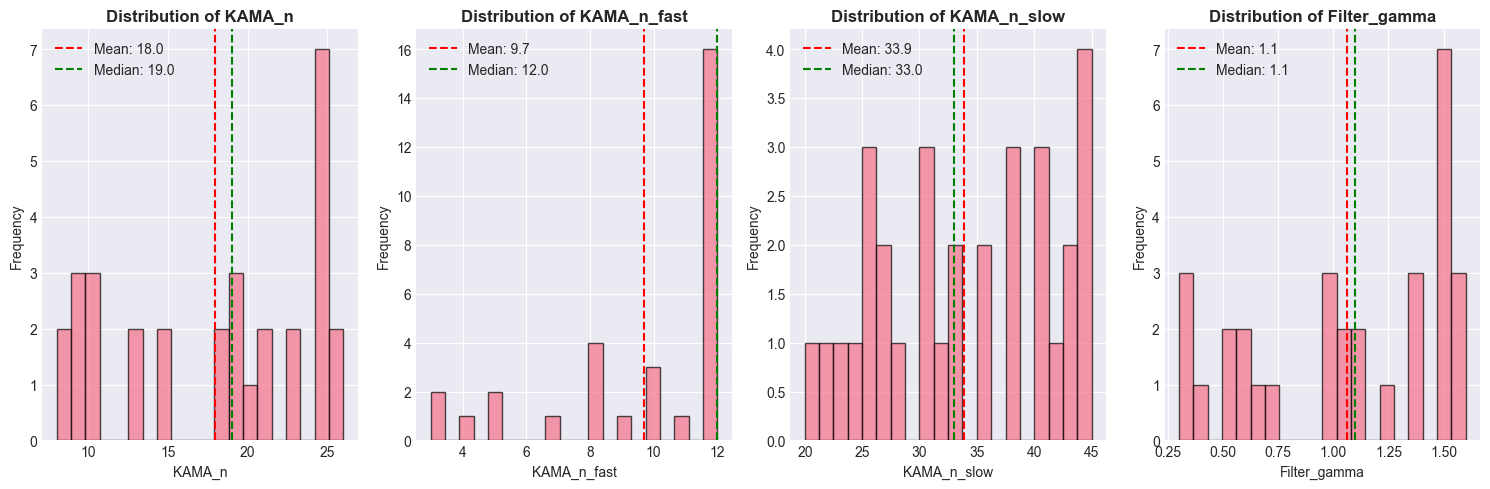

In [14]:
# Visualize KAMA parameters
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for idx, col in enumerate(kama_cols):
    ax = axes[idx]
    metadata_df[col].hist(bins=20, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(metadata_df[col].mean(), color='red', linestyle='--', 
               label=f'Mean: {metadata_df[col].mean():.1f}')
    ax.axvline(metadata_df[col].median(), color='green', linestyle='--', 
               label=f'Median: {metadata_df[col].median():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

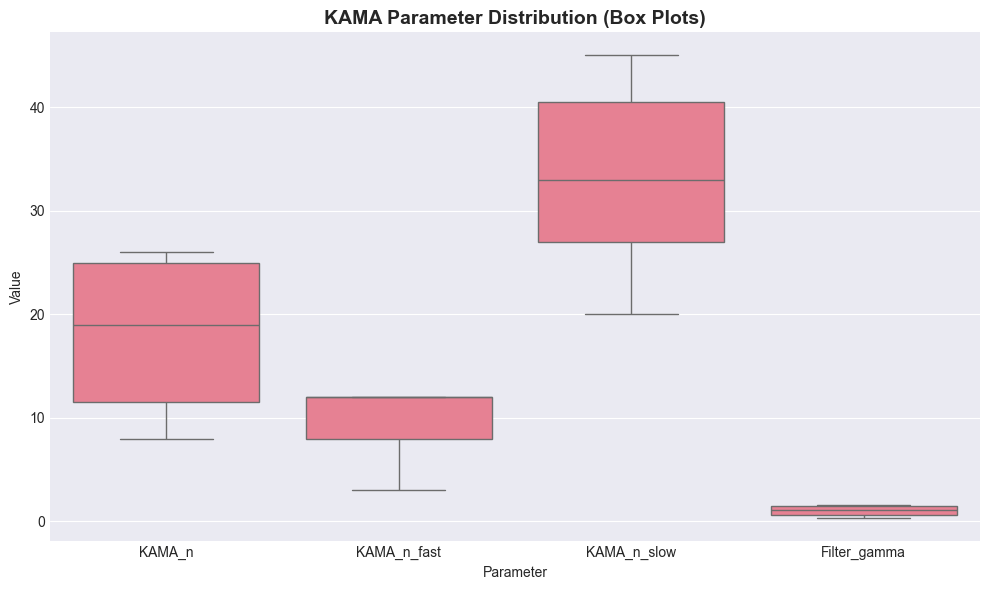


KAMA Parameter Outliers (values > 1.5 IQR):


In [15]:
# Box plots for KAMA parameters
fig, ax = plt.subplots(figsize=(10, 6))

kama_data = metadata_df[kama_cols].melt(var_name='Parameter', value_name='Value')
sns.boxplot(data=kama_data, x='Parameter', y='Value', ax=ax)
ax.set_title('KAMA Parameter Distribution (Box Plots)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify outliers
print("\nKAMA Parameter Outliers (values > 1.5 IQR):")
print("="*80)
for col in kama_cols:
    Q1 = metadata_df[col].quantile(0.25)
    Q3 = metadata_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = metadata_df[(metadata_df[col] < Q1 - 1.5*IQR) | (metadata_df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"\n{col}:")
        for _, row in outliers.iterrows():
            print(f"  {row['Asset']}: {row[col]}")

## 5. Compare MSR Parameters Across Assets

In [16]:
# Extract MSR parameter columns
msr_mean_cols = [col for col in metadata_df.columns if col.startswith('MSR_Mean_')]
msr_std_cols = [col for col in metadata_df.columns if col.startswith('MSR_Std_')]
msr_beta_cols = [col for col in metadata_df.columns if col.startswith('MSR_Beta_')]

print("MSR Parameter Summary Statistics:")
print("="*80)

print("\nMSR Means:")
display(metadata_df[['Asset'] + msr_mean_cols].describe())

print("\nMSR Standard Deviations:")
display(metadata_df[['Asset'] + msr_std_cols].describe())

print("\nMSR Betas:")
display(metadata_df[['Asset'] + msr_beta_cols].describe())

MSR Parameter Summary Statistics:

MSR Means:


,MSR_Mean_0,MSR_Mean_1
count,31.0000,31.0000
mean,0.0004,-0.0034
std,0.0003,0.0019
min,-0.0012,-0.0087
25%,0.0004,-0.0037
50%,0.0004,-0.0028
75%,0.0005,-0.0021
max,0.0009,-0.0009



MSR Standard Deviations:


,MSR_Std_0,MSR_Std_1
count,31.0000,31.0000
mean,0.0132,0.0450
std,0.0028,0.0112
min,0.0100,0.0318
25%,0.0115,0.0372
50%,0.0126,0.0440
75%,0.0138,0.0467
max,0.0235,0.0769



MSR Betas:


,MSR_Beta_0,MSR_Beta_1
count,31.0000,31.0000
mean,-0.0094,-0.0549
std,0.0083,0.0607
min,-0.0289,-0.3443
25%,-0.0141,-0.0555
50%,-0.0079,-0.0513
75%,-0.0040,-0.0284
max,0.0050,0.0102


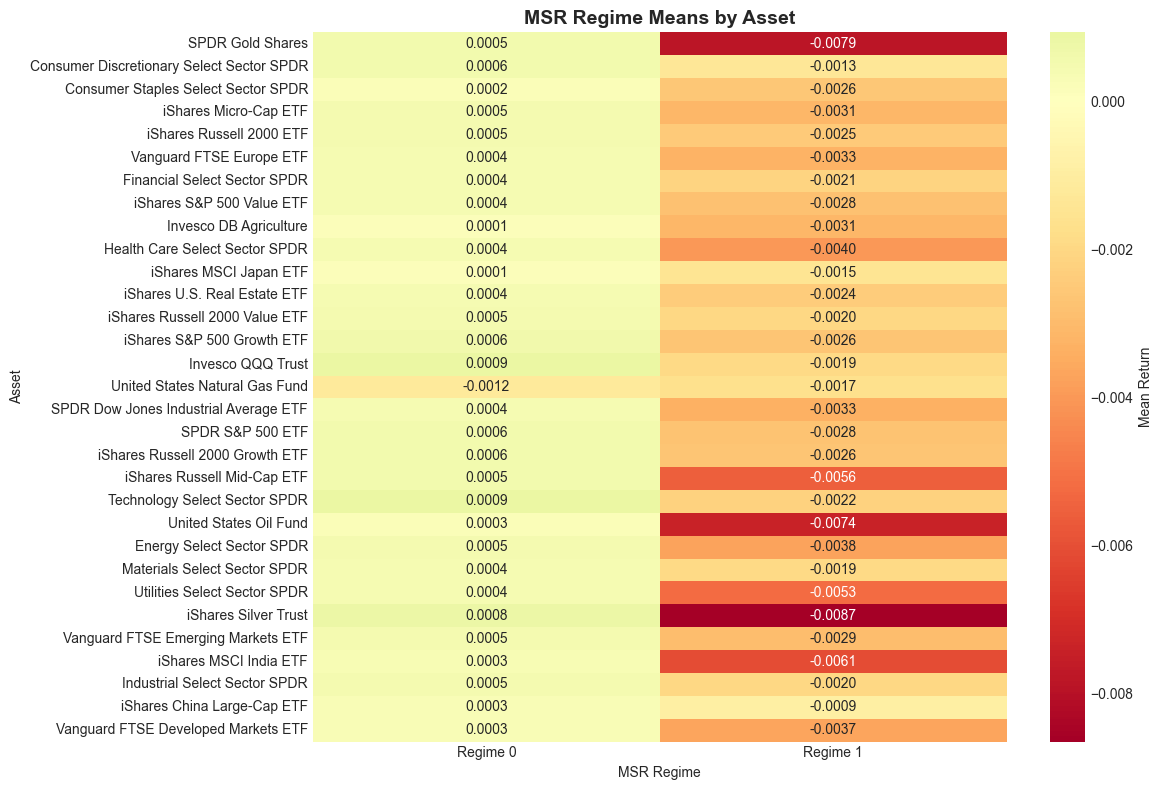

In [17]:
# Heatmap of MSR means
plt.figure(figsize=(12, 8))

msr_means_data = metadata_df[['Asset'] + msr_mean_cols].set_index('Asset')
msr_means_data.columns = [col.replace('MSR_Mean_', 'Regime ') for col in msr_means_data.columns]

sns.heatmap(msr_means_data, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Mean Return'})
plt.title('MSR Regime Means by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

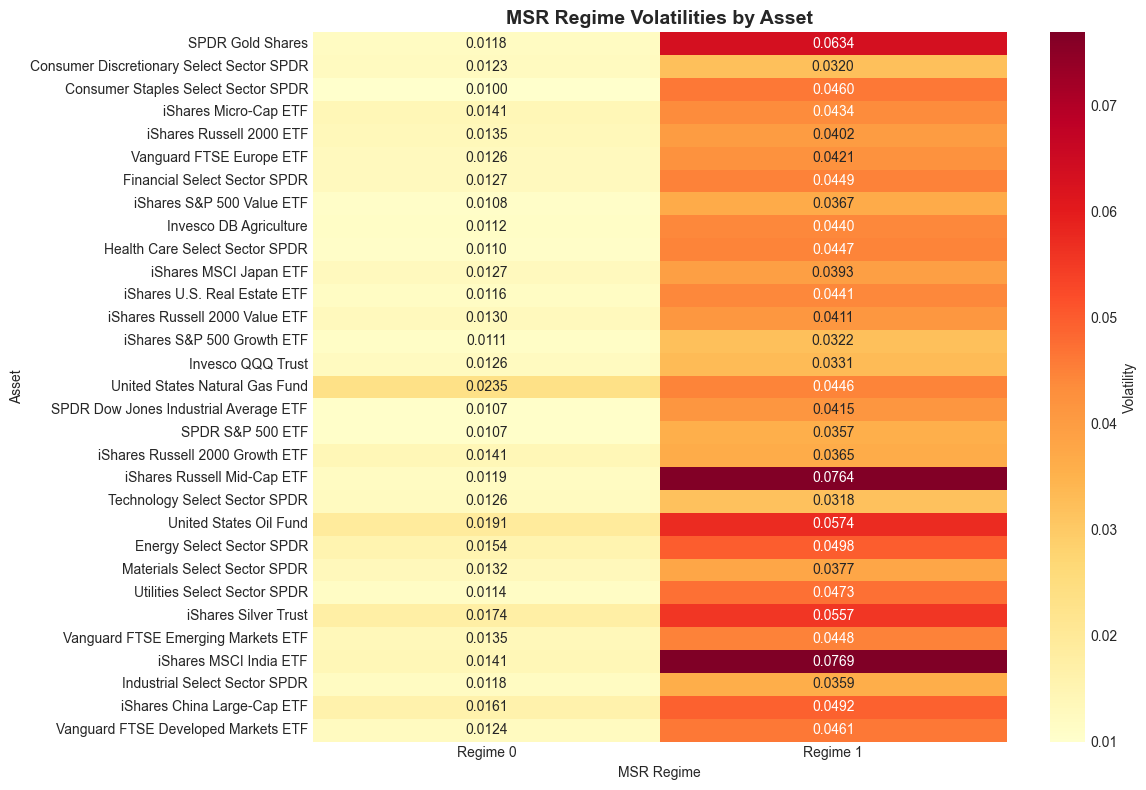

In [18]:
# Heatmap of MSR volatilities
plt.figure(figsize=(12, 8))

msr_stds_data = metadata_df[['Asset'] + msr_std_cols].set_index('Asset')
msr_stds_data.columns = [col.replace('MSR_Std_', 'Regime ') for col in msr_stds_data.columns]

sns.heatmap(msr_stds_data, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': 'Volatility'})
plt.title('MSR Regime Volatilities by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

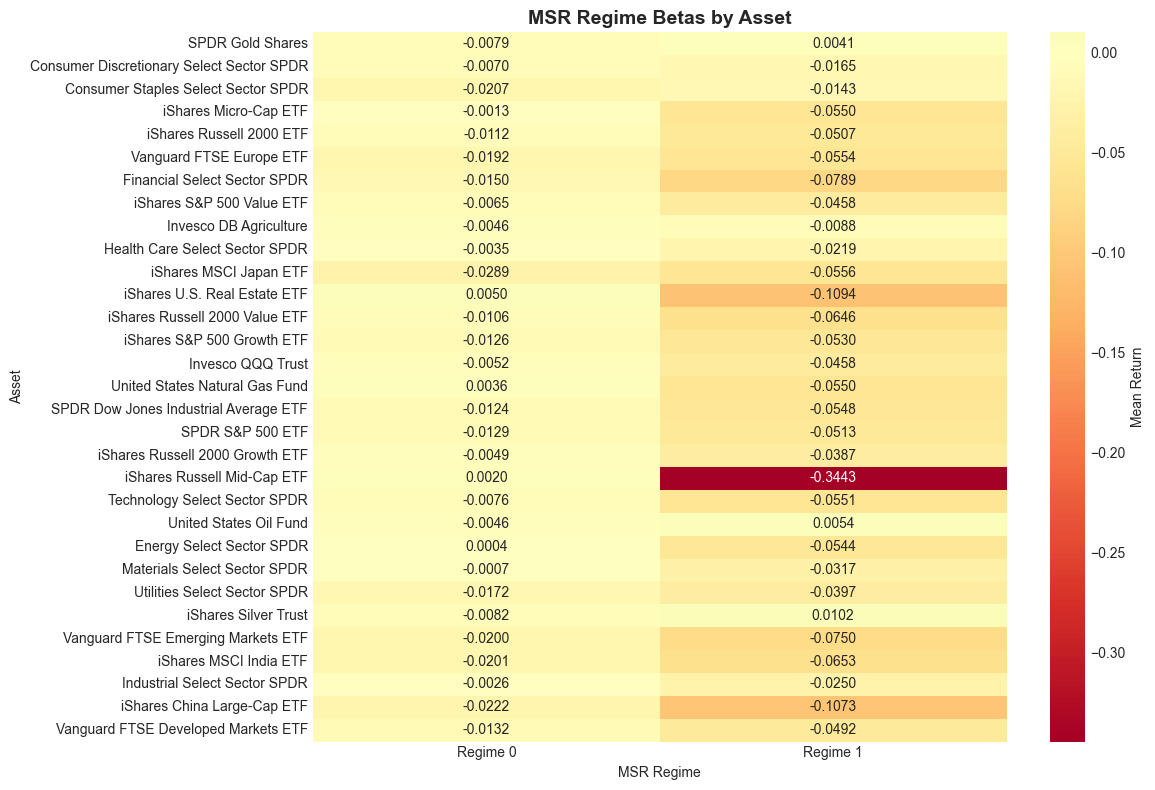

In [19]:
# Heatmap of MSR betas
plt.figure(figsize=(12, 8))

msr_betas_data = metadata_df[['Asset'] + msr_beta_cols].set_index('Asset')
msr_betas_data.columns = [col.replace('MSR_Beta_', 'Regime ') for col in msr_betas_data.columns]

sns.heatmap(msr_betas_data, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Mean Return'})
plt.title('MSR Regime Betas by Asset', fontsize=14, fontweight='bold')
plt.ylabel('Asset')
plt.xlabel('MSR Regime')
plt.tight_layout()
plt.show()

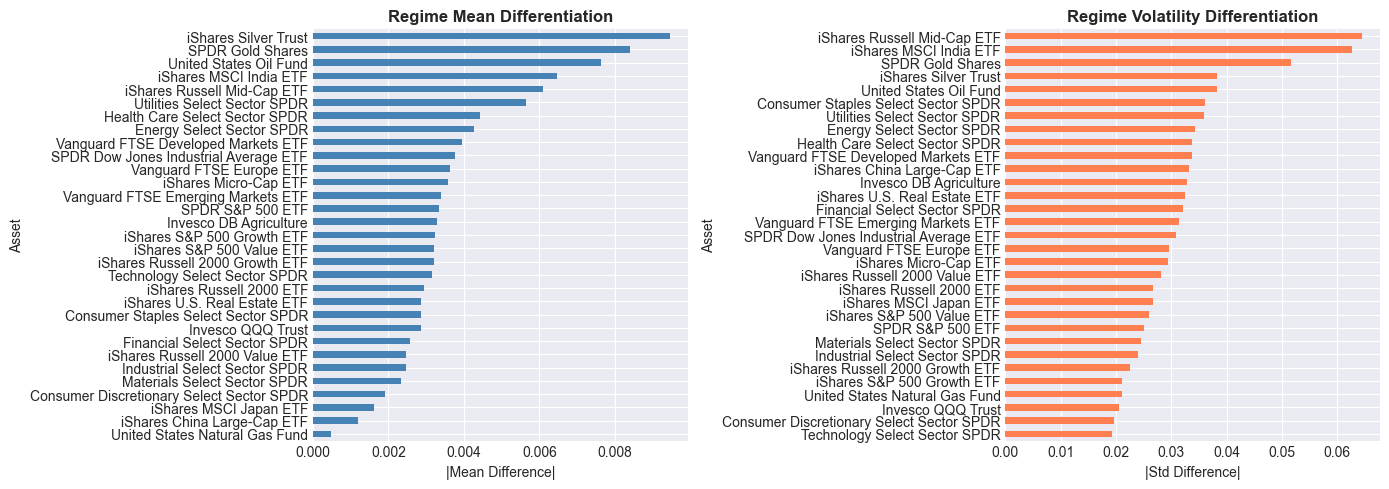


Assets with WEAK Regime Differentiation:

Lowest Mean Differentiation:


,Asset,Mean_Diff,MSR_Mean_0,MSR_Mean_1
15,United States Natural Gas Fund,0.0005,-0.0012,-0.0017
29,iShares China Large-Cap ETF,0.0012,0.0003,-0.0009
10,iShares MSCI Japan ETF,0.0016,0.0001,-0.0015
1,Consumer Discretionary Select Sector SPDR,0.0019,0.0006,-0.0013
23,Materials Select Sector SPDR,0.0023,0.0004,-0.0019



Lowest Volatility Differentiation:


,Asset,Std_Diff,MSR_Std_0,MSR_Std_1
20,Technology Select Sector SPDR,0.0193,0.0126,0.0318
1,Consumer Discretionary Select Sector SPDR,0.0196,0.0123,0.0320
14,Invesco QQQ Trust,0.0205,0.0126,0.0331
15,United States Natural Gas Fund,0.0211,0.0235,0.0446
13,iShares S&P 500 Growth ETF,0.0211,0.0111,0.0322


In [20]:
# Compare regime differentiation (difference between regimes)
if len(msr_mean_cols) == 2:
    metadata_df['Mean_Diff'] = abs(metadata_df['MSR_Mean_0'] - metadata_df['MSR_Mean_1'])
    metadata_df['Std_Diff'] = abs(metadata_df['MSR_Std_0'] - metadata_df['MSR_Std_1'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mean difference
    metadata_df.sort_values('Mean_Diff').plot.barh(x='Asset', y='Mean_Diff', ax=axes[0], 
                                                     color='steelblue', legend=False)
    axes[0].set_title('Regime Mean Differentiation', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('|Mean Difference|')
    
    # Std difference
    metadata_df.sort_values('Std_Diff').plot.barh(x='Asset', y='Std_Diff', ax=axes[1], 
                                                    color='coral', legend=False)
    axes[1].set_title('Regime Volatility Differentiation', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('|Std Difference|')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAssets with WEAK Regime Differentiation:")
    print("="*80)
    print("\nLowest Mean Differentiation:")
    display(metadata_df.nsmallest(5, 'Mean_Diff')[['Asset', 'Mean_Diff', 'MSR_Mean_0', 'MSR_Mean_1']])
    
    print("\nLowest Volatility Differentiation:")
    display(metadata_df.nsmallest(5, 'Std_Diff')[['Asset', 'Std_Diff', 'MSR_Std_0', 'MSR_Std_1']])

## 6. Regime Distribution Analysis

In [21]:
# Regime distribution summary
regime_pct_cols = [col for col in metadata_df.columns if col.startswith('Regime_') and col.endswith('_Pct')]

print("Regime Distribution Summary:")
print("="*80)
display(metadata_df[['Asset'] + regime_pct_cols].describe())

# Identify imbalanced regimes
print("\nAssets with Imbalanced Regime Distributions:")
print("="*80)

for _, row in metadata_df.iterrows():
    pcts = [row[col] for col in regime_pct_cols]
    max_pct = max(pcts)
    min_pct = min(pcts)
    
    if max_pct > 70:  # One regime dominates
        print(f"\n{row['Asset']}:")
        for i, col in enumerate(regime_pct_cols):
            print(f"  Regime {i}: {row[col]:.1f}%")

Regime Distribution Summary:


,Regime_0_Pct,Regime_1_Pct,Regime_2_Pct,Regime_3_Pct
count,31.0000,31.0000,31.0000,31.0000
mean,59.3771,32.2263,1.5026,6.8940
std,13.4995,11.8859,1.7205,4.8027
min,8.3027,15.1051,0.1170,0.6312
25%,54.1660,22.8408,0.4667,3.9701
50%,60.2711,30.6987,1.0097,6.3058
75%,69.1260,39.2182,1.6904,8.2276
max,75.4272,58.6595,8.4541,24.5838



Assets with Imbalanced Regime Distributions:

Consumer Staples Select Sector SPDR:
  Regime 0: 70.9%
  Regime 1: 27.0%
  Regime 2: 0.2%
  Regime 3: 1.9%

iShares S&P 500 Value ETF:
  Regime 0: 71.9%
  Regime 1: 20.7%
  Regime 2: 0.6%
  Regime 3: 6.9%

Health Care Select Sector SPDR:
  Regime 0: 73.6%
  Regime 1: 23.4%
  Regime 2: 0.7%
  Regime 3: 2.4%

SPDR Dow Jones Industrial Average ETF:
  Regime 0: 75.2%
  Regime 1: 20.2%
  Regime 2: 0.3%
  Regime 3: 4.3%

SPDR S&P 500 ETF:
  Regime 0: 75.4%
  Regime 1: 18.0%
  Regime 2: 0.8%
  Regime 3: 5.7%

iShares Russell Mid-Cap ETF:
  Regime 0: 72.1%
  Regime 1: 24.1%
  Regime 2: 0.2%
  Regime 3: 3.7%

Industrial Select Sector SPDR:
  Regime 0: 74.2%
  Regime 1: 17.7%
  Regime 2: 1.0%
  Regime 3: 7.1%


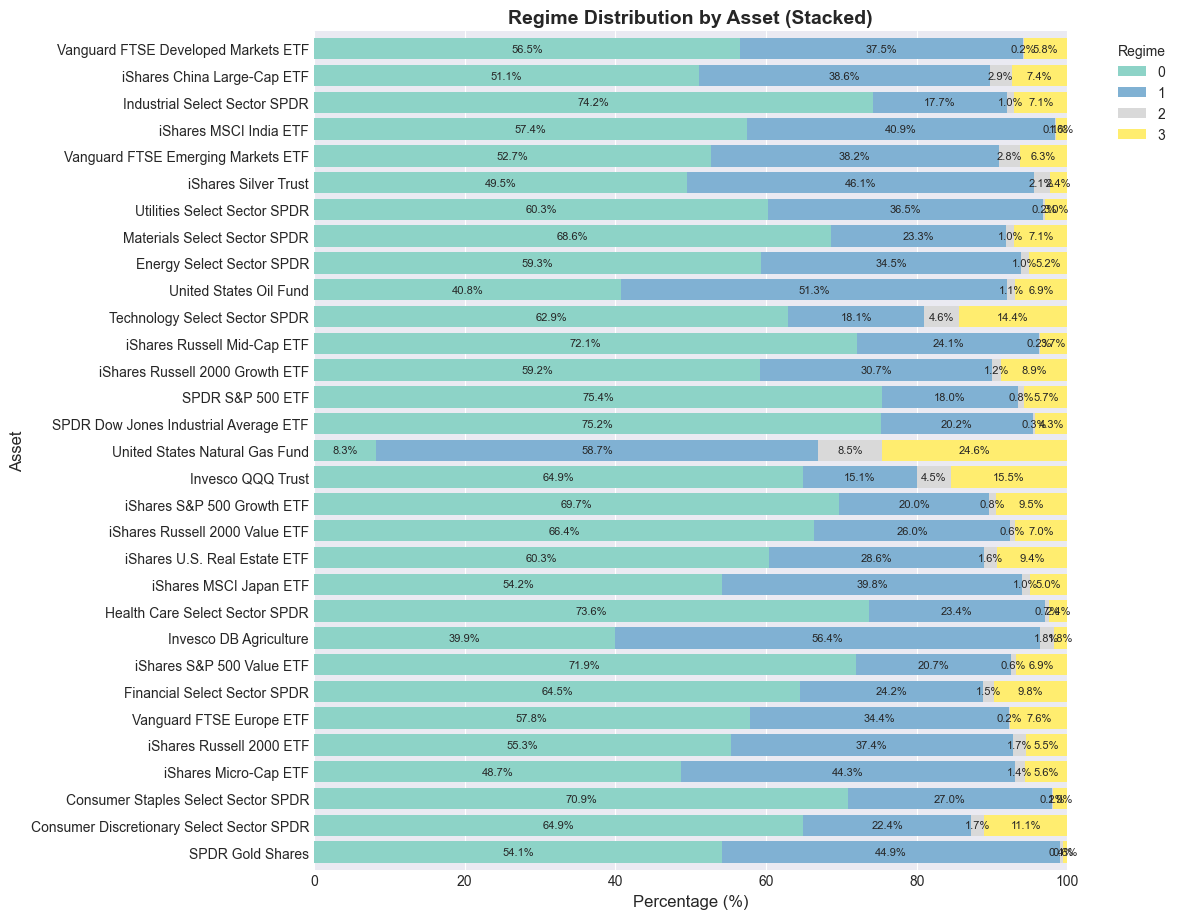

In [22]:
# Stacked bar chart of regime distributions
regime_pct_data = metadata_df[['Asset'] + regime_pct_cols].set_index('Asset')
regime_pct_data.columns = [col.replace('Regime_', '').replace('_Pct', '') for col in regime_pct_data.columns]

ax = regime_pct_data.plot.barh(stacked=True, figsize=(12, max(8, len(models)*0.3)), 
                                colormap='Set3', width=0.8)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Asset', fontsize=12)
ax.set_title('Regime Distribution by Asset (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0, 100)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

Regime Diversity Scores:
(0 = Perfectly balanced, 1 = Completely concentrated)



,Asset,Regime_Diversity_Score,Regime_0_Pct,Regime_1_Pct,Regime_2_Pct,Regime_3_Pct
2,Consumer Staples Select Sector SPDR,0.5057,70.8829,27.0214,0.2081,1.8876
9,Health Care Select Sector SPDR,0.5042,73.5995,23.3611,0.6555,2.3838
16,SPDR Dow Jones Industrial Average ETF,0.5016,75.2192,20.1667,0.3306,4.2835
19,iShares Russell Mid-Cap ETF,0.4878,72.1133,24.0652,0.1647,3.6567
17,SPDR S&P 500 ETF,0.4766,75.4272,17.9829,0.8415,5.7483
0,SPDR Gold Shares,0.4625,54.1316,44.8546,0.3826,0.6312
27,iShares MSCI India ETF,0.4541,57.4144,40.9184,0.1170,1.5502
28,Industrial Select Sector SPDR,0.4509,74.1974,17.7319,0.9810,7.0898
7,iShares S&P 500 Value ETF,0.4402,71.8873,20.6831,0.5509,6.8786
24,Utilities Select Sector SPDR,0.4283,60.2711,36.4964,0.2383,2.9942


<Figure size 1000x930 with 0 Axes>

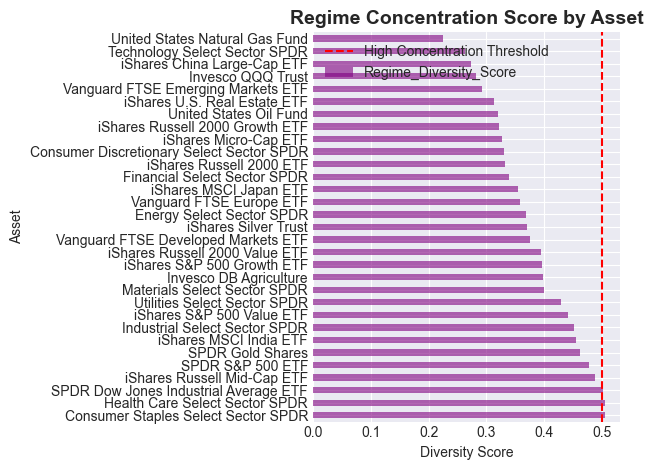

In [23]:
# Regime diversity metric (entropy-based)
from scipy.stats import entropy

def regime_diversity_score(pcts):
    """Calculate normalized entropy as diversity score (0=uniform, 1=concentrated)"""
    pcts_normalized = np.array(pcts) / 100.0
    max_entropy = np.log(len(pcts))
    return 1 - (entropy(pcts_normalized) / max_entropy) if max_entropy > 0 else 0

metadata_df['Regime_Diversity_Score'] = metadata_df.apply(
    lambda row: regime_diversity_score([row[col] for col in regime_pct_cols]), axis=1
)

print("Regime Diversity Scores:")
print("="*80)
print("(0 = Perfectly balanced, 1 = Completely concentrated)\n")

diversity_sorted = metadata_df[['Asset', 'Regime_Diversity_Score'] + regime_pct_cols].sort_values('Regime_Diversity_Score', ascending=False)
display(diversity_sorted)

# Visualize
plt.figure(figsize=(10, max(6, len(models)*0.3)))
diversity_sorted.plot.barh(x='Asset', y='Regime_Diversity_Score', 
                           color='purple', alpha=0.6, legend=False)
plt.axvline(0.5, color='red', linestyle='--', label='High Concentration Threshold')
plt.xlabel('Diversity Score')
plt.ylabel('Asset')
plt.title('Regime Concentration Score by Asset', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Regime Duration Analysis

In [24]:
def extract_regime_duration_stats(models: Dict) -> pd.DataFrame:
    """
    Extract regime duration statistics from all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Regime duration statistics for all models
    """
    duration_stats = []
    
    for asset_name, model in models.items():
        try:
            regime_labels = model.regime_labels.dropna()
            
            # Calculate regime durations
            regime_changes = regime_labels != regime_labels.shift(1)
            regime_blocks = regime_changes.cumsum()
            
            durations = regime_labels.groupby(regime_blocks).size()
            
            stats = {
                'Asset': asset_name,
                'Mean_Duration': durations.mean(),
                'Median_Duration': durations.median(),
                'Std_Duration': durations.std(),
                'Min_Duration': durations.min(),
                'Max_Duration': durations.max(),
                'Q25_Duration': durations.quantile(0.25),
                'Q75_Duration': durations.quantile(0.75),
                'N_Regimes': len(durations),
                'Pct_Single_Period': (durations == 1).sum() / len(durations) * 100
            }
            
            duration_stats.append(stats)
            
        except Exception as e:
            print(f"❌ Error extracting duration stats for {asset_name}: {str(e)}")
    
    return pd.DataFrame(duration_stats)

duration_df = extract_regime_duration_stats(models)

print("Regime Duration Statistics:")
print("="*80)
display(duration_df.sort_values('Mean_Duration', ascending=False))

Regime Duration Statistics:


,Asset,Mean_Duration,Median_Duration,Std_Duration,Min_Duration,Max_Duration,Q25_Duration,Q75_Duration,N_Regimes,Pct_Single_Period
8,Invesco DB Agriculture,85.3091,16.0,212.1487,1,1428,3.00,54.50,55,9.0909
7,iShares S&P 500 Value ETF,81.4359,24.0,169.8694,1,1121,9.00,74.25,78,1.2821
12,iShares Russell 2000 Value ETF,74.2824,27.0,145.3832,1,1060,6.00,80.00,85,9.4118
5,Vanguard FTSE Europe ETF,70.6164,37.0,98.6351,1,555,9.00,77.00,73,5.4795
15,United States Natural Gas Fund,68.0000,41.0,87.4776,1,503,22.00,81.75,68,2.9412
17,SPDR S&P 500 ETF,64.8992,14.0,125.0591,1,801,6.00,54.00,119,9.2437
26,Vanguard FTSE Emerging Markets ETF,62.8415,32.0,81.1296,2,359,12.25,75.00,82,0.0000
19,iShares Russell Mid-Cap ETF,62.5773,20.0,104.9273,1,481,4.00,66.00,97,10.3093
14,Invesco QQQ Trust,59.9910,27.0,101.9483,1,662,7.50,54.50,111,5.4054
22,Energy Select Sector SPDR,59.9286,19.0,97.3704,1,512,6.75,69.75,112,6.2500


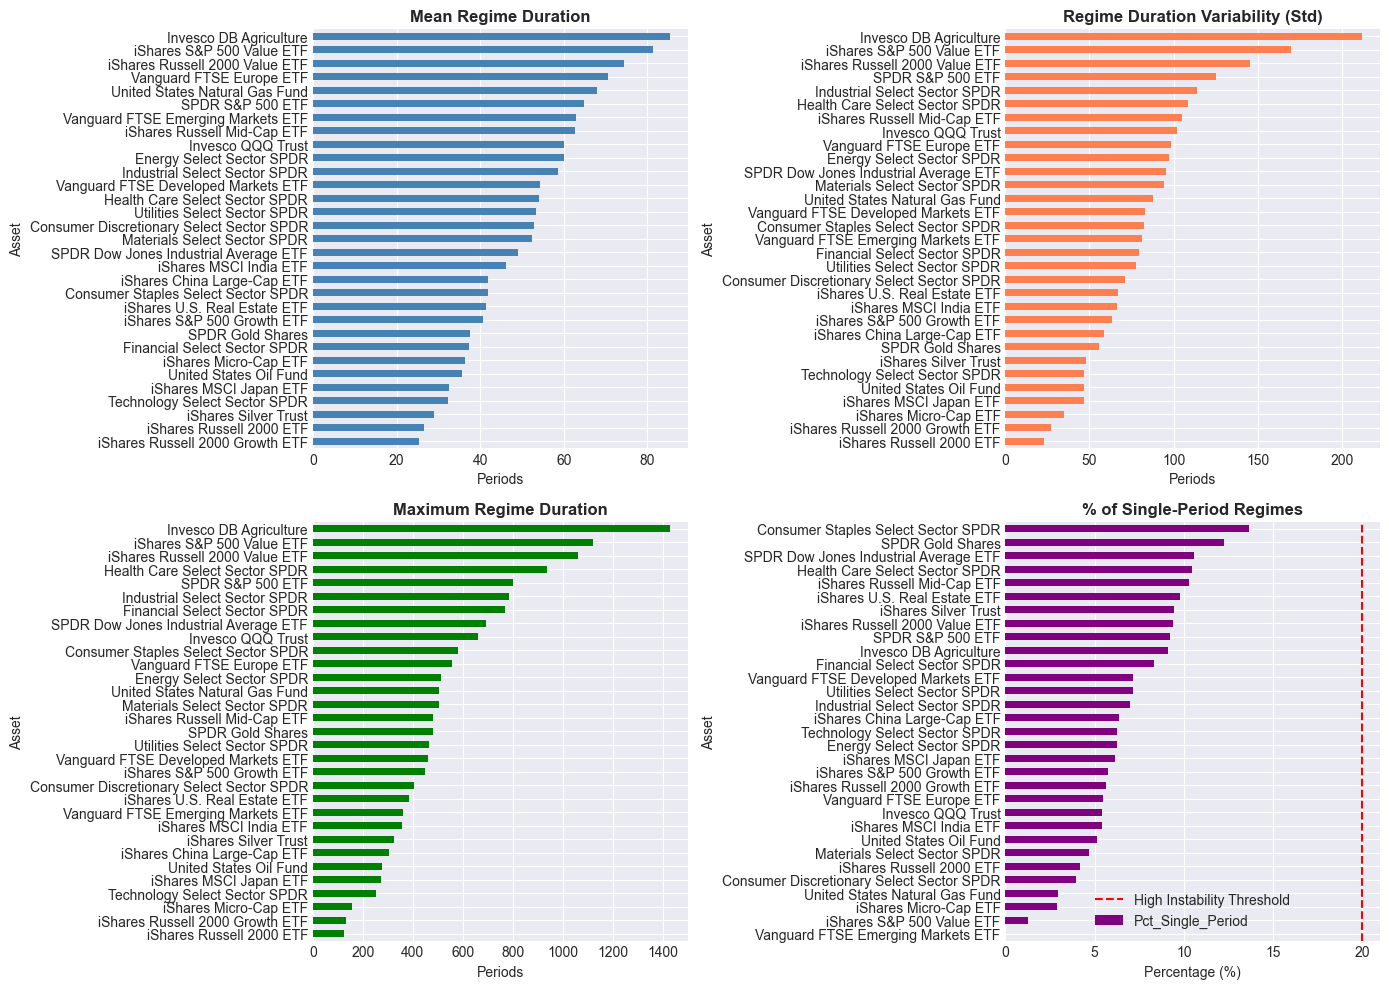

In [25]:
# Visualize regime duration characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean duration
duration_df.sort_values('Mean_Duration').plot.barh(x='Asset', y='Mean_Duration', 
                                                     ax=axes[0,0], color='steelblue', legend=False)
axes[0,0].set_title('Mean Regime Duration', fontweight='bold')
axes[0,0].set_xlabel('Periods')

# Duration variability (std)
duration_df.sort_values('Std_Duration').plot.barh(x='Asset', y='Std_Duration', 
                                                    ax=axes[0,1], color='coral', legend=False)
axes[0,1].set_title('Regime Duration Variability (Std)', fontweight='bold')
axes[0,1].set_xlabel('Periods')

# Max duration
duration_df.sort_values('Max_Duration').plot.barh(x='Asset', y='Max_Duration', 
                                                    ax=axes[1,0], color='green', legend=False)
axes[1,0].set_title('Maximum Regime Duration', fontweight='bold')
axes[1,0].set_xlabel('Periods')

# Percentage of single-period regimes
duration_df.sort_values('Pct_Single_Period').plot.barh(x='Asset', y='Pct_Single_Period', 
                                                         ax=axes[1,1], color='purple', legend=False)
axes[1,1].set_title('% of Single-Period Regimes', fontweight='bold')
axes[1,1].set_xlabel('Percentage (%)')
axes[1,1].axvline(20, color='red', linestyle='--', label='High Instability Threshold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [26]:
# Identify problematic duration patterns
print("Assets with Regime Duration Issues:")
print("="*80)

print("\n1. HIGH REGIME INSTABILITY (>20% single-period regimes):")
unstable = duration_df[duration_df['Pct_Single_Period'] > 20].sort_values('Pct_Single_Period', ascending=False)
if len(unstable) > 0:
    display(unstable[['Asset', 'Pct_Single_Period', 'Mean_Duration', 'N_Regimes']])
else:
    print("  ✓ None found")

print("\n2. VERY SHORT AVERAGE DURATIONS (<5 periods):")
short_duration = duration_df[duration_df['Mean_Duration'] < 5].sort_values('Mean_Duration')
if len(short_duration) > 0:
    display(short_duration[['Asset', 'Mean_Duration', 'Median_Duration', 'Pct_Single_Period']])
else:
    print("  ✓ None found")

print("\n3. VERY LONG AVERAGE DURATIONS (>50 periods):")
long_duration = duration_df[duration_df['Mean_Duration'] > 50].sort_values('Mean_Duration', ascending=False)
if len(long_duration) > 0:
    display(long_duration[['Asset', 'Mean_Duration', 'Max_Duration', 'N_Regimes']])
else:
    print("  ✓ None found")

Assets with Regime Duration Issues:

1. HIGH REGIME INSTABILITY (>20% single-period regimes):
  ✓ None found

2. VERY SHORT AVERAGE DURATIONS (<5 periods):
  ✓ None found

3. VERY LONG AVERAGE DURATIONS (>50 periods):


,Asset,Mean_Duration,Max_Duration,N_Regimes
8,Invesco DB Agriculture,85.3091,1428,55
7,iShares S&P 500 Value ETF,81.4359,1121,78
12,iShares Russell 2000 Value ETF,74.2824,1060,85
5,Vanguard FTSE Europe ETF,70.6164,555,73
15,United States Natural Gas Fund,68.0000,503,68
17,SPDR S&P 500 ETF,64.8992,801,119
26,Vanguard FTSE Emerging Markets ETF,62.8415,359,82
19,iShares Russell Mid-Cap ETF,62.5773,481,97
14,Invesco QQQ Trust,59.9910,662,111
22,Energy Select Sector SPDR,59.9286,512,112


## 8. Transition Probability Comparison

In [27]:
# Extract transition probability columns
trans_prob_cols = [col for col in metadata_df.columns if col.startswith('Trans_P_')]

print("Transition Probability Summary:")
print("="*80)
display(metadata_df[['Asset'] + trans_prob_cols].describe())

# Calculate average transition probabilities
print("\n\nAverage Transition Probabilities Across All Assets:")
avg_trans_probs = metadata_df[trans_prob_cols].mean()
for col in trans_prob_cols:
    from_regime = col.split('_')[2]
    to_regime = col.split('_')[4]
    print(f"  P({from_regime} → {to_regime}): {avg_trans_probs[col]:.4f}")

Transition Probability Summary:


,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1
count,31.0000,31.0000,31.0000,31.0000
mean,0.9934,0.0066,0.0973,0.9027
std,0.0023,0.0023,0.0814,0.0814
min,0.9859,0.0045,0.0256,0.5682
25%,0.9926,0.0051,0.0546,0.8918
50%,0.9940,0.0060,0.0674,0.9326
75%,0.9949,0.0074,0.1082,0.9454
max,0.9955,0.0141,0.4318,0.9744




Average Transition Probabilities Across All Assets:
  P(0 → 0): 0.9934
  P(0 → 1): 0.0066
  P(1 → 0): 0.0973
  P(1 → 1): 0.9027


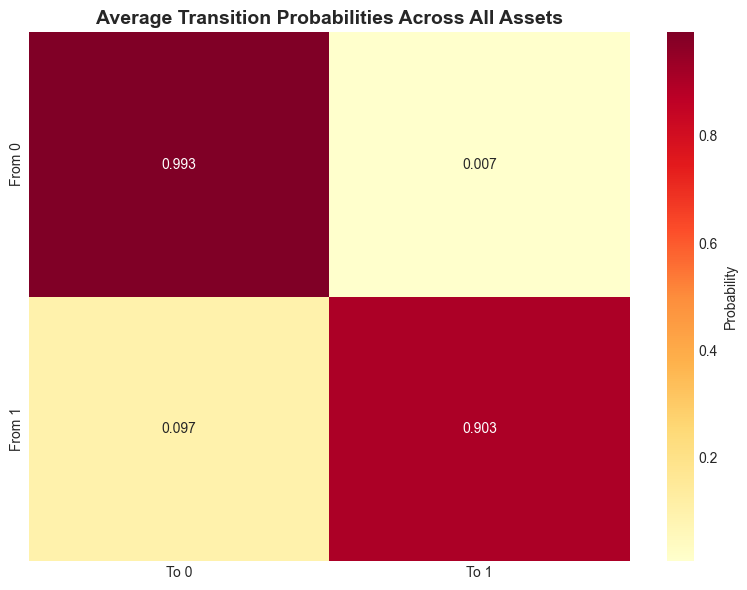

In [28]:
# Heatmap of average transition probabilities
n_msr_regimes = models[list(models.keys())[0]].msr.n_regimes

avg_trans_matrix = np.zeros((n_msr_regimes, n_msr_regimes))

for i in range(n_msr_regimes):
    for j in range(n_msr_regimes):
        col_name = f'Trans_P_{i}_to_{j}'
        avg_trans_matrix[i, j] = metadata_df[col_name].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(avg_trans_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=[f'To {i}' for i in range(n_msr_regimes)],
            yticklabels=[f'From {i}' for i in range(n_msr_regimes)],
            cbar_kws={'label': 'Probability'})
plt.title('Average Transition Probabilities Across All Assets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Identify assets with unusual transition probabilities
print("Assets with Unusual Transition Probabilities:")
print("="*80)

# Calculate persistence (diagonal probabilities)
for i in range(n_msr_regimes):
    col_name = f'Trans_P_{i}_to_{i}'
    metadata_df[f'Persistence_{i}'] = metadata_df[col_name]

persistence_cols = [f'Persistence_{i}' for i in range(n_msr_regimes)]

print("\nPersistence Probabilities (P(stay in same regime)):")
display(metadata_df[['Asset'] + persistence_cols].sort_values(persistence_cols[0]))

# Very low persistence (< 0.8)
print("\n\nAssets with LOW PERSISTENCE (<0.8):")
for i, col in enumerate(persistence_cols):
    low_persist = metadata_df[metadata_df[col] < 0.8][['Asset', col]]
    if len(low_persist) > 0:
        print(f"\nRegime {i}:")
        display(low_persist.sort_values(col))

Assets with Unusual Transition Probabilities:

Persistence Probabilities (P(stay in same regime)):


,Asset,Persistence_0,Persistence_1
25,iShares Silver Trust,0.9859,0.7846
15,United States Natural Gas Fund,0.9873,0.9732
21,United States Oil Fund,0.9904,0.8996
29,iShares China Large-Cap ETF,0.9910,0.9286
10,iShares MSCI Japan ETF,0.9916,0.8880
6,Financial Select Sector SPDR,0.9918,0.9392
20,Technology Select Sector SPDR,0.9922,0.9676
0,SPDR Gold Shares,0.9924,0.5682
13,iShares S&P 500 Growth ETF,0.9928,0.9397
8,Invesco DB Agriculture,0.9931,0.8421




Assets with LOW PERSISTENCE (<0.8):

Regime 1:


,Asset,Persistence_1
0,SPDR Gold Shares,0.5682
27,iShares MSCI India ETF,0.7529
25,iShares Silver Trust,0.7846


## 9. Return Characteristics by Regime

In [30]:
def calculate_regime_return_characteristics(models: Dict) -> pd.DataFrame:
    """
    Calculate return statistics for each regime across all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Return characteristics by regime for all assets
    """
    regime_stats = []
    
    for asset_name, model in models.items():
        try:
            returns = model.returns.dropna()
            regime_labels = model.regime_labels.dropna()
            
            # Align on common index
            common_idx = returns.index.intersection(regime_labels.index)
            returns_aligned = returns.loc[common_idx]
            regime_labels_aligned = regime_labels.loc[common_idx]
            
            for regime in regime_labels_aligned.unique():
                if pd.isna(regime):
                    continue
                
                regime_mask = regime_labels_aligned == regime
                regime_returns = returns_aligned[regime_mask]
                
                if len(regime_returns) > 0:
                    stats = {
                        'Asset': asset_name,
                        'Regime': int(regime),
                        'N_Obs': len(regime_returns),
                        'Mean': regime_returns.mean(),
                        'Std': regime_returns.std(),
                        'Sharpe': regime_returns.mean() / regime_returns.std() * np.sqrt(252) if regime_returns.std() > 0 else 0,
                        'Skewness': skew(regime_returns),
                        'Kurtosis': kurtosis(regime_returns),
                        'Min': regime_returns.min(),
                        'Max': regime_returns.max(),
                        'Pct_Positive': (regime_returns > 0).sum() / len(regime_returns) * 100
                    }
                    
                    regime_stats.append(stats)
        
        except Exception as e:
            print(f"❌ Error calculating return characteristics for {asset_name}: {str(e)}")
    
    return pd.DataFrame(regime_stats)

regime_returns_df = calculate_regime_return_characteristics(models)
regime_returns_df['Mean'] *= 252  # Annualize mean returns
regime_returns_df['Std'] *= np.sqrt(252)  # Annualize std dev

print("Regime Return Characteristics:")
print("="*80)
display(regime_returns_df.groupby('Regime')[['Mean', 'Std', 'Sharpe', 'Skewness', 'Kurtosis']].describe().T\
        .rename(columns={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'}))


Regime Return Characteristics:


Regime          Low Vol Bull  Low Vol Bear  High Vol Bull  High Vol Bear
Mean     count       31.0000       31.0000        31.0000        31.0000
         mean         0.0915        0.1609        -3.2110        -0.6253
         std          0.0510        0.1265         2.4661         0.5608
         min          0.0008       -0.3464        -7.9660        -2.3859
         25%          0.0514        0.1161        -4.6837        -0.7599
         50%          0.0893        0.1865        -2.2822        -0.4683
         75%          0.1203        0.2190        -1.3455        -0.2970
         max          0.2005        0.3459         0.0877         0.1002
Std      count       31.0000       31.0000        31.0000        31.0000
         mean         0.1712        0.2125         0.5195         0.6324
         std          0.0459        0.0398         0.1489         0.1426
         min          0.1154        0.1332         0.3305         0.4485
         25%          0.1424        0.1938         0.4310         0.5160
         50%          0.1614        0.2140         0.4858         0.5905
         75%          0.1764        0.2233         0.5281         0.7061
         max          0.3258        0.3518         0.9601         0.9485
Sharpe   count       31.0000       31.0000        31.0000        31.0000
         mean         0.5545        0.7969        -6.6236        -0.9358
         std          0.3137        0.5328         5.4207         0.6701
         min          0.0053       -0.9845       -19.0304        -2.6813
         25%          0.3212        0.6585       -12.1196        -1.2421
         50%          0.5168        0.8946        -4.6627        -0.7700
         75%          0.7464        0.9996        -2.5105        -0.4996
         max          1.2426        1.7067         0.1984         0.1853
Skewness count       31.0000       31.0000        31.0000        31.0000
         mean        -0.2682       -0.0408         0.2844        -0.0381
         std          0.1216        0.0700         0.4925         0.2579
         min         -0.4942       -0.1950        -0.4395        -0.6186
         25%         -0.3754       -0.0912        -0.0409        -0.2511
         50%         -0.2560       -0.0435         0.1550        -0.0482
         75%         -0.1763        0.0018         0.4044         0.1260
         max         -0.0501        0.1125         1.4948         0.4180
Kurtosis count       31.0000       31.0000        31.0000        31.0000
         mean         1.1808        0.4447        -0.1668         1.3498
         std          0.3739        0.4690         0.8584         2.4765
         min          0.2232       -0.0714        -1.9455        -0.5704
         25%          0.9795        0.1569        -0.6476         0.3928
         50%          1.2272        0.2705        -0.4588         0.8549
         75%          1.4703        0.5721         0.1003         1.4568
         max          1.7283        1.8716         1.7221        13.9618

In [31]:
regime_returns_df.set_index(['Asset', 'Regime']).sort_index()

N_Obs    Mean     Std  Sharpe  Skewness  Kurtosis     Min     Max  \
Asset                                     Regime                                                                      
Consumer Discretionary Select Sector SPDR 0        4356  0.1267  0.1535  0.8251   -0.2963    1.3138 -0.0461  0.0424   
                                          1        1502  0.1787  0.2176  0.8213   -0.0460    0.0660 -0.0432  0.0485   
                                          2         112 -1.7764  0.3908 -4.5456    0.0264   -0.0742 -0.0826  0.0509   
                                          3         743 -0.1072  0.4593 -0.2334   -0.1755    1.3307 -0.1355  0.1034   
Consumer Staples Select Sector SPDR       0        4769  0.0377  0.1154  0.3268   -0.3315    1.7283 -0.0387  0.0332   
...                                                 ...     ...     ...     ...       ...       ...     ...     ...   
iShares Silver Trust                      3         116 -2.3859  0.8898 -2.6813   -0.3548    0.3507 -0.1983  0.1347   
iShares U.S. Real Estate ETF              0        3831  0.1020  0.1442  0.7074   -0.3939    1.6163 -0.0435  0.0368   
                                          1        1818  0.1275  0.1819  0.7010   -0.1950    0.5642 -0.0399  0.0422   
                                          2         104 -1.9684  0.4257 -4.6243    0.2076   -0.1831 -0.0770  0.0638   
                                          3         595 -0.2909  0.6851 -0.4246   -0.2877    2.5071 -0.2308  0.1512   

                                                  Pct_Positive  
Asset                                     Regime                
Consumer Discretionary Select Sector SPDR 0            53.6501  
                                          1            52.8628  
                                          2            37.5000  
                                          3            49.1252  
Consumer Staples Select Sector SPDR       0            52.0445  
...                                                        ...  
iShares Silver Trust                      3            43.9655  
iShares U.S. Real Estate ETF              0            53.9024  
                                          1            53.7404  
                                          2            33.6538  
                                          3            48.4034  

[124 rows x 9 columns]

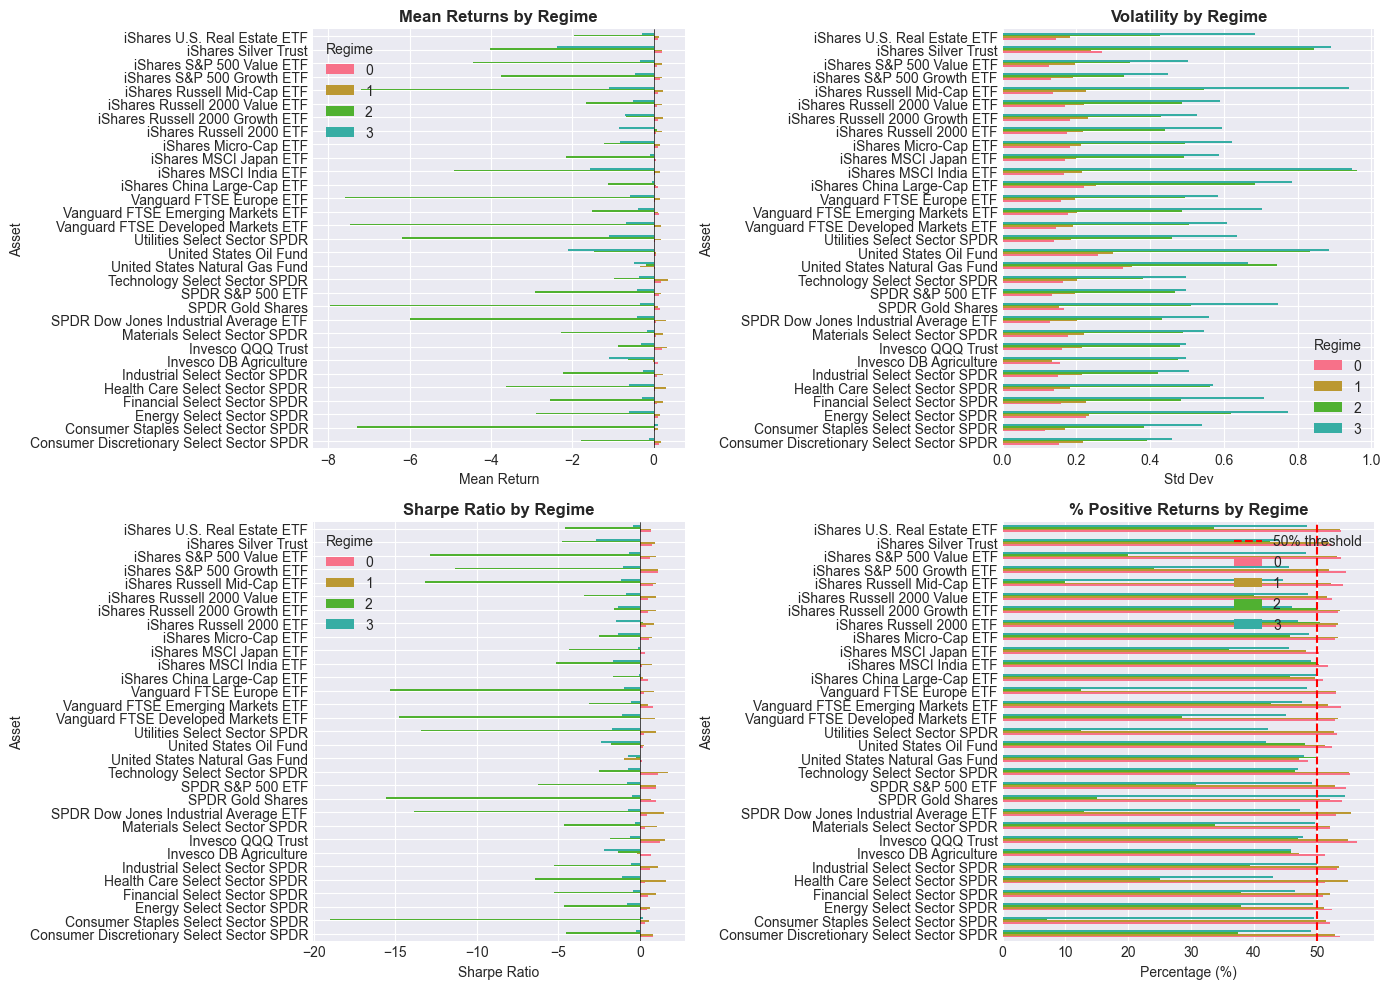

In [32]:
# Compare return characteristics across regimes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean returns by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Mean').plot.barh(ax=axes[0,0])
axes[0,0].set_title('Mean Returns by Regime', fontweight='bold')
axes[0,0].set_xlabel('Mean Return')
axes[0,0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Volatility by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Std').plot.barh(ax=axes[0,1])
axes[0,1].set_title('Volatility by Regime', fontweight='bold')
axes[0,1].set_xlabel('Std Dev')

# Sharpe ratio by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Sharpe').plot.barh(ax=axes[1,0])
axes[1,0].set_title('Sharpe Ratio by Regime', fontweight='bold')
axes[1,0].set_xlabel('Sharpe Ratio')
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Percentage positive by regime
regime_returns_df.pivot(index='Asset', columns='Regime', values='Pct_Positive').plot.barh(ax=axes[1,1])
axes[1,1].set_title('% Positive Returns by Regime', fontweight='bold')
axes[1,1].set_xlabel('Percentage (%)')
axes[1,1].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [33]:
# Identify poorly differentiated regimes based on returns
print("Regime Differentiation Analysis:")
print("="*80)

for asset_name in regime_returns_df['Asset'].unique():
    asset_data = regime_returns_df[regime_returns_df['Asset'] == asset_name]
    
    if len(asset_data) >= 2:
        # Check if regimes have similar returns
        mean_diff = abs(asset_data['Mean'].max() - asset_data['Mean'].min())
        std_diff = abs(asset_data['Std'].max() - asset_data['Std'].min())
        
        # Flag if differences are small
        if mean_diff < 0.0005:  # Very small mean difference
            print(f"\n⚠️  {asset_name}: WEAK Mean Differentiation")
            print(f"   Mean difference: {mean_diff:.6f}")
            display(asset_data[['Regime', 'Mean', 'Std', 'Sharpe']])

Regime Differentiation Analysis:


## 10. Model Performance Metrics

In [34]:
def calculate_model_performance_metrics(models: Dict) -> pd.DataFrame:
    """
    Calculate performance metrics for all models.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Performance metrics for all models
    """
    performance_metrics = []
    
    for asset_name, model in models.items():
        try:
            returns = model.returns.dropna()
            regime_labels = model.regime_labels.dropna()
            
            # Align returns and regime_labels on common index
            common_idx = returns.index.intersection(regime_labels.index)
            returns_aligned = returns.loc[common_idx]
            regime_labels_aligned = regime_labels.loc[common_idx]
            
            # Number of parameters
            n_regimes = model.msr.n_regimes
            n_params = n_regimes * 3 + n_regimes * (n_regimes - 1)  # means, stds, betas, transition probs
            
            # Log-likelihood (approximate)
            log_likelihood = 0
            for regime in range(n_regimes):
                regime_mask = regime_labels_aligned == regime
                regime_returns = returns_aligned[regime_mask]
                if len(regime_returns) > 0:
                    ll = -0.5 * len(regime_returns) * np.log(2 * np.pi * model.msr.stds[regime]**2)
                    ll -= np.sum((regime_returns - model.msr.means[regime])**2) / (2 * model.msr.stds[regime]**2)
                    log_likelihood += ll
            
            # AIC and BIC
            n_obs = len(returns_aligned)
            aic = 2 * n_params - 2 * log_likelihood
            bic = n_params * np.log(n_obs) - 2 * log_likelihood
            
            metrics = {
                'Asset': asset_name,
                'Log_Likelihood': log_likelihood,
                'AIC': aic,
                'BIC': bic,
                'N_Params': n_params,
                'N_Obs': n_obs,
                'AIC_per_Obs': aic / n_obs,
                'BIC_per_Obs': bic / n_obs
            }
            
            performance_metrics.append(metrics)
            
        except Exception as e:
            print(f"❌ Error calculating performance metrics for {asset_name}: {str(e)}")
    
    return pd.DataFrame(performance_metrics)

performance_df = calculate_model_performance_metrics(models)

print("Model Performance Metrics:")
print("="*80)
if len(performance_df) > 0:
    display(performance_df.sort_values('BIC'))
else:
    print("❌ No performance metrics calculated")


Model Performance Metrics:


,Asset,Log_Likelihood,AIC,BIC,N_Params,N_Obs,AIC_per_Obs,BIC_per_Obs
17,SPDR S&P 500 ETF,22564.2122,-45112.4244,-45056.8077,8,7724,-5.8406,-5.8334
16,SPDR Dow Jones Industrial Average ETF,20562.0246,-41108.0492,-41053.2692,8,6957,-5.9089,-5.9010
2,Consumer Staples Select Sector SPDR,20199.5676,-40383.1353,-40328.6230,8,6728,-6.0022,-5.9941
9,Health Care Select Sector SPDR,19553.6787,-39091.3574,-39036.8642,8,6712,-5.8241,-5.8160
10,iShares MSCI Japan ETF,19163.7657,-38311.5314,-38256.2273,8,7428,-5.1577,-5.1503
28,Industrial Select Sector SPDR,18741.6264,-37467.2528,-37412.7405,8,6728,-5.5689,-5.5608
7,iShares S&P 500 Value ETF,18312.2033,-36608.4066,-36554.3532,8,6353,-5.7624,-5.7539
24,Utilities Select Sector SPDR,18288.9017,-36561.8034,-36507.3090,8,6713,-5.4464,-5.4383
13,iShares S&P 500 Growth ETF,17758.5633,-35501.1266,-35447.0517,8,6370,-5.5732,-5.5647
23,Materials Select Sector SPDR,17654.9974,-35293.9948,-35239.4933,8,6719,-5.2529,-5.2448


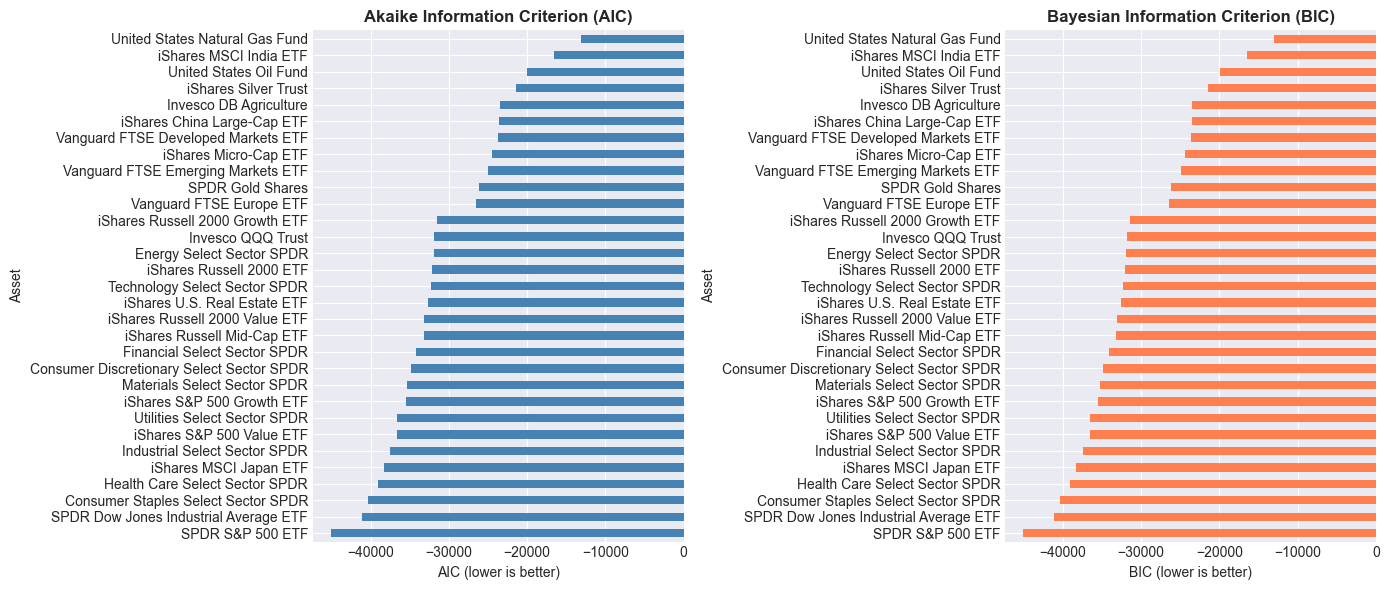


Best Performing Models (by BIC):


,Asset,Log_Likelihood,AIC,BIC
17,SPDR S&P 500 ETF,22564.2122,-45112.4244,-45056.8077
16,SPDR Dow Jones Industrial Average ETF,20562.0246,-41108.0492,-41053.2692
2,Consumer Staples Select Sector SPDR,20199.5676,-40383.1353,-40328.6230
9,Health Care Select Sector SPDR,19553.6787,-39091.3574,-39036.8642
10,iShares MSCI Japan ETF,19163.7657,-38311.5314,-38256.2273



Worst Performing Models (by BIC):


,Asset,Log_Likelihood,AIC,BIC
15,United States Natural Gas Fund,6550.8408,-13085.6816,-13034.1678
27,iShares MSCI India ETF,8288.4369,-16560.8739,-16511.7770
21,United States Oil Fund,10017.4320,-20018.8640,-19966.9159
25,iShares Silver Trust,10731.8375,-21447.6750,-21395.7285
8,Invesco DB Agriculture,11753.6990,-23491.3980,-23439.7674


In [35]:
# Visualize performance metrics
if len(performance_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # AIC
    performance_df.sort_values('AIC').plot.barh(x='Asset', y='AIC', ax=axes[0], 
                                                 color='steelblue', legend=False)
    axes[0].set_title('Akaike Information Criterion (AIC)', fontweight='bold')
    axes[0].set_xlabel('AIC (lower is better)')

    # BIC
    performance_df.sort_values('BIC').plot.barh(x='Asset', y='BIC', ax=axes[1], 
                                                 color='coral', legend=False)
    axes[1].set_title('Bayesian Information Criterion (BIC)', fontweight='bold')
    axes[1].set_xlabel('BIC (lower is better)')

    plt.tight_layout()
    plt.show()

    print("\nBest Performing Models (by BIC):")
    display(performance_df.nsmallest(5, 'BIC')[['Asset', 'Log_Likelihood', 'AIC', 'BIC']])

    print("\nWorst Performing Models (by BIC):")
    display(performance_df.nlargest(5, 'BIC')[['Asset', 'Log_Likelihood', 'AIC', 'BIC']])
else:
    print("❌ No performance data to visualize")


## 11. Regime Stability Analysis

In [36]:
# Combine with earlier duration metrics
stability_df = metadata_df[['Asset', 'N_Regime_Changes', 'Avg_Regime_Duration']].merge(
    duration_df[['Asset', 'Pct_Single_Period', 'Std_Duration']], 
    on='Asset'
)

# Add regime change frequency
stability_df['Changes_Per_100_Periods'] = (stability_df['N_Regime_Changes'] / 
                                           metadata_df['N_Data_Points'] * 100)

print("Regime Stability Metrics:")
print("="*80)
display(stability_df.sort_values('Changes_Per_100_Periods', ascending=False))

Regime Stability Metrics:


,Asset,N_Regime_Changes,Avg_Regime_Duration,Pct_Single_Period,Std_Duration,Changes_Per_100_Periods
18,iShares Russell 2000 Growth ETF,248,25.4056,5.6225,27.0555,3.9141
4,iShares Russell 2000 ETF,238,26.6318,4.1841,22.9556,3.7310
25,iShares Silver Trust,168,28.8876,9.4675,47.9434,3.4342
20,Technology Select Sector SPDR,207,32.3558,6.2500,46.8946,3.0717
10,iShares MSCI Japan ETF,227,32.5789,6.1404,46.6557,3.0519
21,United States Oil Fund,136,35.6423,5.1095,46.6761,2.7727
3,iShares Micro-Cap ETF,138,36.2734,2.8777,34.7224,2.7230
6,Financial Select Sector SPDR,179,37.3778,8.3333,79.1561,2.6562
0,SPDR Gold Shares,138,37.6115,12.2302,55.5846,2.6266
13,iShares S&P 500 Growth ETF,156,40.5732,5.7325,63.2820,2.4455


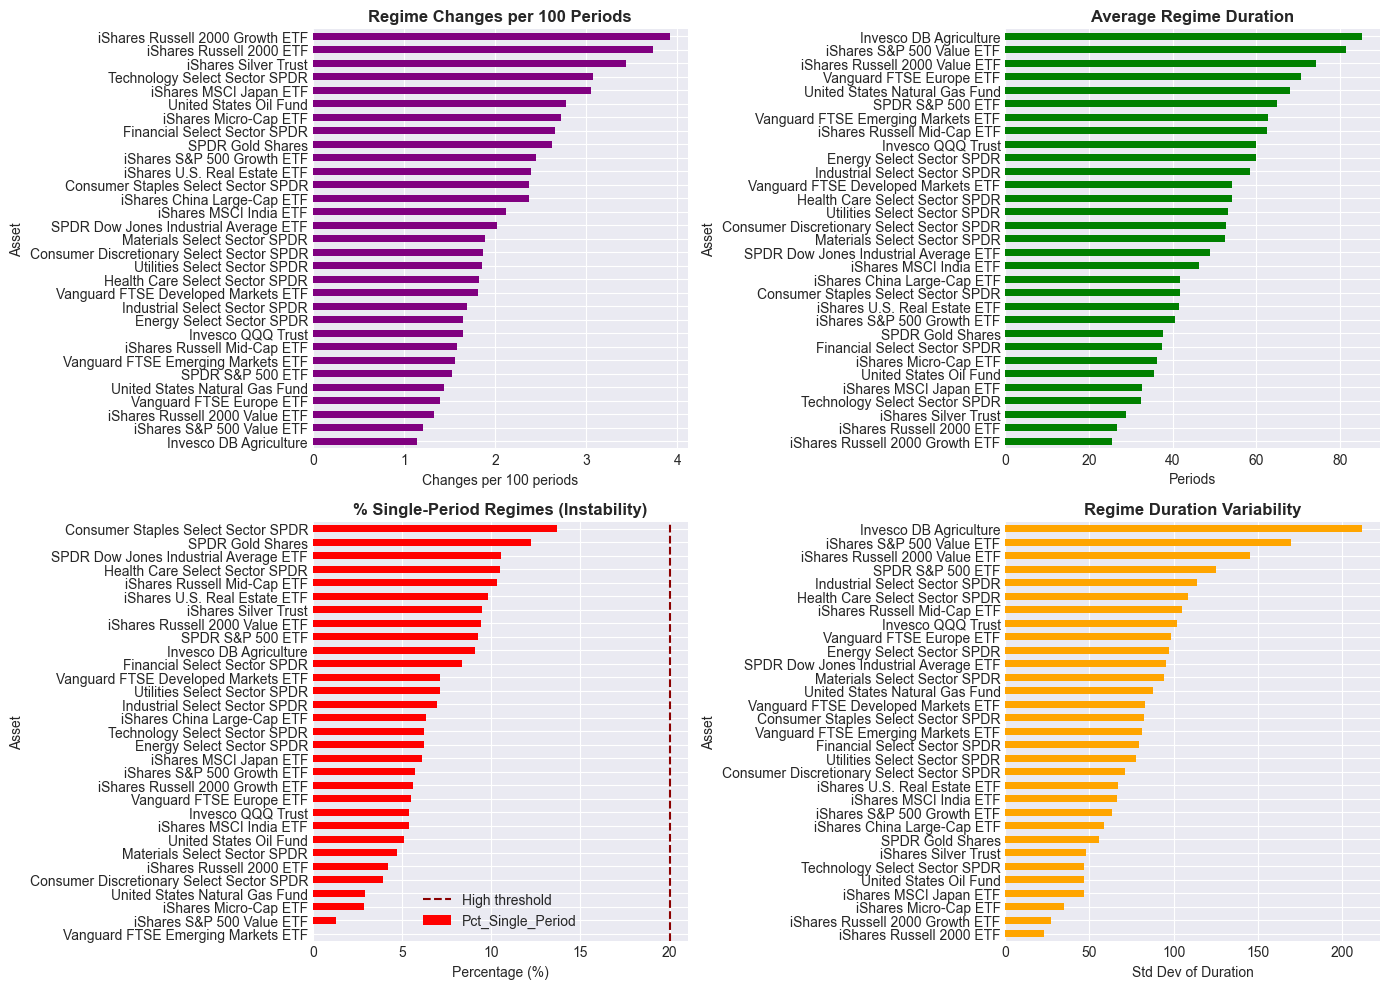

In [37]:
# Visualize stability metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime changes per 100 periods
stability_df.sort_values('Changes_Per_100_Periods').plot.barh(
    x='Asset', y='Changes_Per_100_Periods', ax=axes[0,0], color='purple', legend=False
)
axes[0,0].set_title('Regime Changes per 100 Periods', fontweight='bold')
axes[0,0].set_xlabel('Changes per 100 periods')

# Average regime duration
stability_df.sort_values('Avg_Regime_Duration').plot.barh(
    x='Asset', y='Avg_Regime_Duration', ax=axes[0,1], color='green', legend=False
)
axes[0,1].set_title('Average Regime Duration', fontweight='bold')
axes[0,1].set_xlabel('Periods')

# Percentage single-period regimes
stability_df.sort_values('Pct_Single_Period').plot.barh(
    x='Asset', y='Pct_Single_Period', ax=axes[1,0], color='red', legend=False
)
axes[1,0].set_title('% Single-Period Regimes (Instability)', fontweight='bold')
axes[1,0].set_xlabel('Percentage (%)')
axes[1,0].axvline(20, color='darkred', linestyle='--', label='High threshold')
axes[1,0].legend()

# Duration variability
stability_df.sort_values('Std_Duration').plot.barh(
    x='Asset', y='Std_Duration', ax=axes[1,1], color='orange', legend=False
)
axes[1,1].set_title('Regime Duration Variability', fontweight='bold')
axes[1,1].set_xlabel('Std Dev of Duration')

plt.tight_layout()
plt.show()

In [38]:
# Identify unstable models
print("Models with Stability Issues:")
print("="*80)

print("\n1. HIGH REGIME SWITCHING (>15 changes per 100 periods):")
high_switching = stability_df[stability_df['Changes_Per_100_Periods'] > 15].sort_values(
    'Changes_Per_100_Periods', ascending=False
)
if len(high_switching) > 0:
    display(high_switching)
else:
    print("  ✓ None found")

print("\n2. HIGH INSTABILITY (>20% single-period regimes):")
high_instability = stability_df[stability_df['Pct_Single_Period'] > 20].sort_values(
    'Pct_Single_Period', ascending=False
)
if len(high_instability) > 0:
    display(high_instability)
else:
    print("  ✓ None found")

Models with Stability Issues:

1. HIGH REGIME SWITCHING (>15 changes per 100 periods):
  ✓ None found

2. HIGH INSTABILITY (>20% single-period regimes):
  ✓ None found


## 12. Parameter Sensitivity Visualization

In [39]:
# Merge all dataframes for comprehensive analysis
comprehensive_df = metadata_df.merge(duration_df, on='Asset', suffixes=('', '_dur'))
comprehensive_df = comprehensive_df.merge(performance_df, on='Asset')
comprehensive_df = comprehensive_df.merge(stability_df[['Asset', 'Changes_Per_100_Periods']], on='Asset')

print("Comprehensive Dataset Shape:", comprehensive_df.shape)
print("\nFirst few rows:")
display(comprehensive_df.head())

Comprehensive Dataset Shape: (31, 50)

First few rows:


,Asset,N_Data_Points,N_MSR_Regimes,N_Combined_Regimes,KAMA_n,KAMA_n_fast,KAMA_n_slow,Filter_gamma,N_Regime_Changes,Avg_Regime_Duration,Regime_0_Pct,Regime_0_Count,Regime_1_Pct,Regime_1_Count,Regime_2_Pct,Regime_2_Count,Regime_3_Pct,Regime_3_Count,MSR_Mean_0,MSR_Std_0,MSR_Beta_0,MSR_Mean_1,MSR_Std_1,MSR_Beta_1,Trans_P_0_to_0,Trans_P_0_to_1,Trans_P_1_to_0,Trans_P_1_to_1,Mean_Diff,Std_Diff,Regime_Diversity_Score,Persistence_0,Persistence_1,Mean_Duration,Median_Duration,Std_Duration,Min_Duration,Max_Duration,Q25_Duration,Q75_Duration,N_Regimes,Pct_Single_Period,Log_Likelihood,AIC,BIC,N_Params,N_Obs,AIC_per_Obs,BIC_per_Obs,Changes_Per_100_Periods
0,SPDR Gold Shares,5254,2,4,25,5,23,1.00,138,37.6115,54.1316,2830,44.8546,2345,0.3826,20,0.6312,33,0.0005,0.0118,-0.0079,-0.0079,0.0634,0.0041,0.9924,0.0076,0.4318,0.5682,0.0084,0.0516,0.4625,0.9924,0.5682,37.6043,18.0,55.5846,1,480,4.0,51.0,139,12.2302,13098.1742,-26180.3484,-26127.8542,8,5228,-5.0077,-4.9977,2.6266
1,Consumer Discretionary Select Sector SPDR,6739,2,4,25,5,40,1.05,126,52.8583,64.8890,4356,22.3745,1502,1.6684,112,11.0681,743,0.0006,0.0123,-0.0070,-0.0013,0.0320,-0.0165,0.9933,0.0067,0.0441,0.9559,0.0019,0.0196,0.3309,0.9933,0.9559,52.8504,24.0,70.8598,1,404,9.0,68.0,127,3.9370,17453.9162,-34891.8325,-34837.3381,8,6713,-5.1977,-5.1895,1.8697
2,Consumer Staples Select Sector SPDR,6739,2,4,10,12,38,0.30,160,41.7888,70.8829,4769,27.0214,1818,0.2081,14,1.8876,127,0.0002,0.0100,-0.0207,-0.0026,0.0460,-0.0143,0.9951,0.0049,0.1718,0.8282,0.0029,0.0361,0.5057,0.9951,0.8282,41.7826,13.0,82.2708,1,579,3.0,37.0,161,13.6646,20199.5676,-40383.1353,-40328.6230,8,6728,-6.0022,-5.9941,2.3742
3,iShares Micro-Cap ETF,5068,2,4,25,3,26,0.75,138,36.2734,48.7108,2456,44.2880,2233,1.3883,70,5.6129,283,0.0005,0.0141,-0.0013,-0.0031,0.0434,-0.0550,0.9949,0.0051,0.0635,0.9365,0.0036,0.0293,0.3276,0.9949,0.9365,36.2662,25.0,34.7224,1,156,9.0,50.0,139,2.8777,12228.7956,-24441.5912,-24389.3868,8,5042,-4.8476,-4.8372,2.7230
4,iShares Russell 2000 ETF,6379,2,4,13,3,24,1.00,238,26.6318,55.3496,3523,37.3920,2380,1.7125,109,5.5460,353,0.0005,0.0135,-0.0112,-0.0025,0.0402,-0.0507,0.9955,0.0045,0.0561,0.9439,0.0029,0.0267,0.3326,0.9955,0.9439,26.6276,20.0,22.9556,1,124,10.5,36.0,239,4.1841,16059.6379,-32103.2759,-32049.2073,8,6365,-5.0437,-5.0352,3.7310


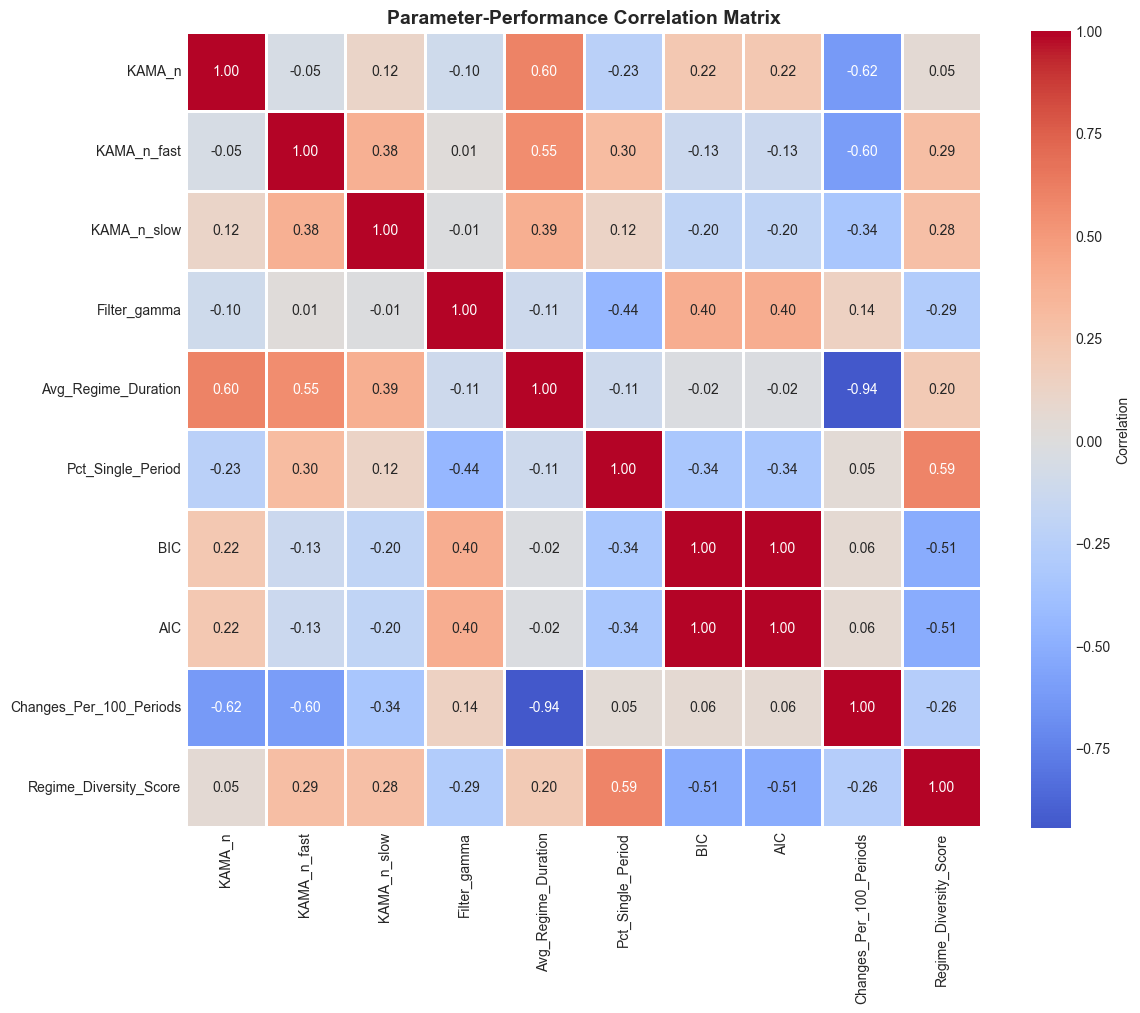


Strongest Correlations with Performance Metrics:

Correlations with BIC (model quality):
  AIC: 1.000
  Regime_Diversity_Score: -0.514
  Filter_gamma: 0.397
  Pct_Single_Period: -0.337
  KAMA_n: 0.222


In [40]:
# Correlation matrix of key parameters and performance metrics
key_columns = [
    'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma',
    'Avg_Regime_Duration', 'Pct_Single_Period',
    'BIC', 'AIC', 'Changes_Per_100_Periods',
    'Regime_Diversity_Score'
]

# Filter columns that exist
available_cols = [col for col in key_columns if col in comprehensive_df.columns]

correlation_matrix = comprehensive_df[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Parameter-Performance Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStrongest Correlations with Performance Metrics:")
print("="*80)

# Find strongest correlations with BIC
if 'BIC' in correlation_matrix.columns:
    bic_corr = correlation_matrix['BIC'].drop('BIC').abs().sort_values(ascending=False)
    print("\nCorrelations with BIC (model quality):")
    for param, corr in bic_corr.head(5).items():
        print(f"  {param}: {correlation_matrix.loc[param, 'BIC']:.3f}")

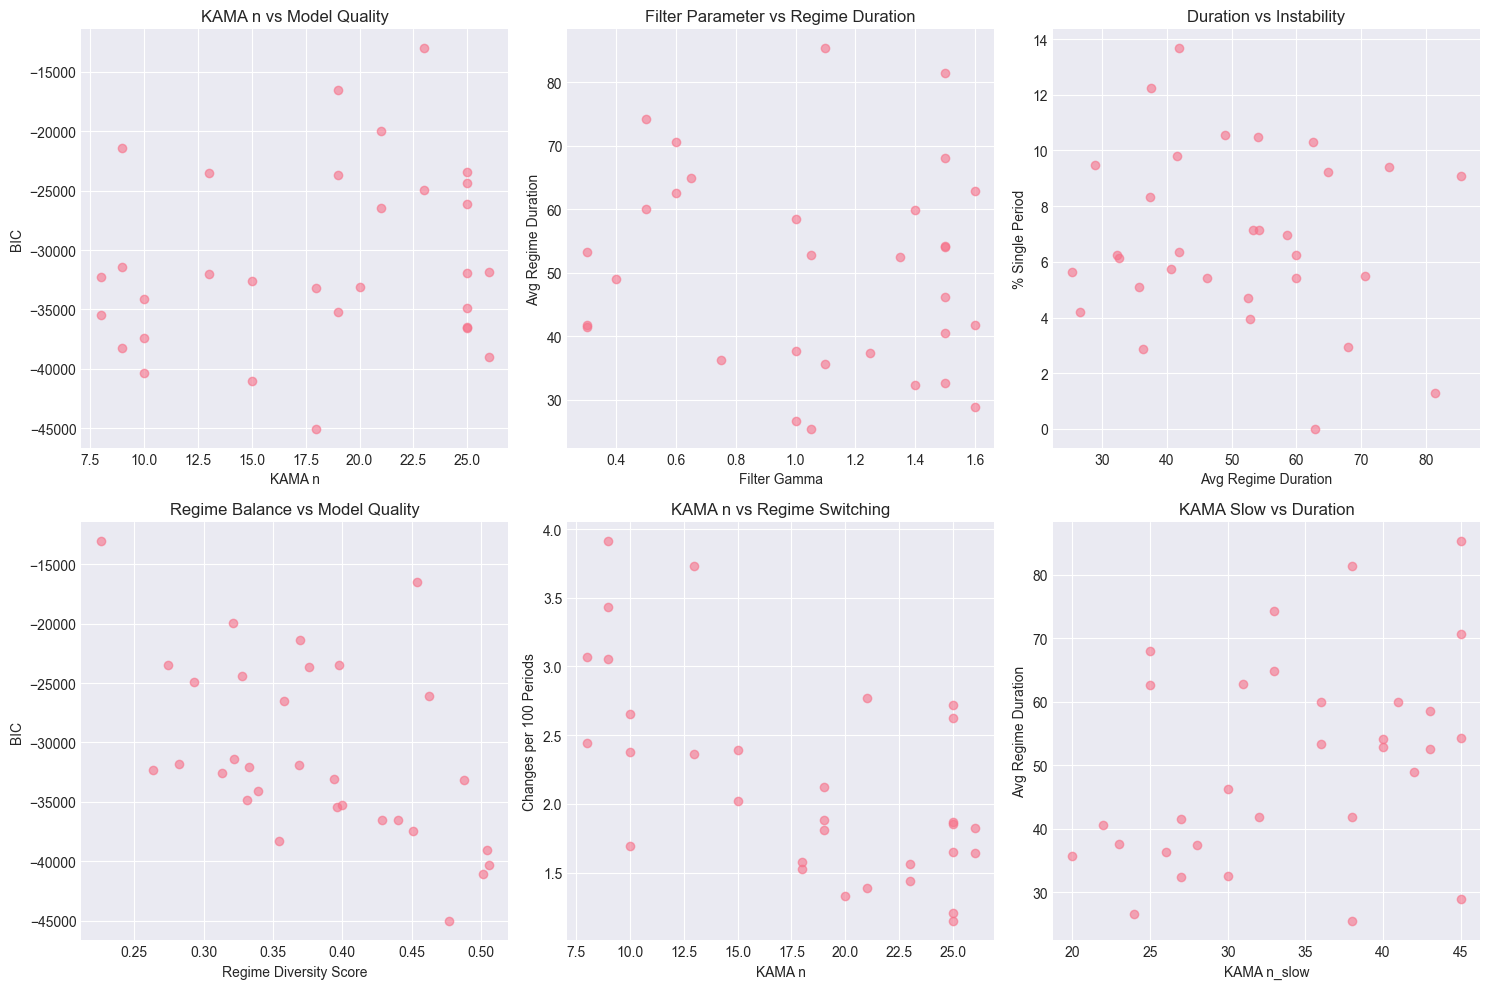

In [41]:
# Scatter plots of key relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# KAMA_n vs BIC
if 'BIC' in comprehensive_df.columns:
    axes[0,0].scatter(comprehensive_df['KAMA_n'], comprehensive_df['BIC'], alpha=0.6)
    axes[0,0].set_xlabel('KAMA n')
    axes[0,0].set_ylabel('BIC')
    axes[0,0].set_title('KAMA n vs Model Quality')

# Filter gamma vs Avg Duration
axes[0,1].scatter(comprehensive_df['Filter_gamma'], comprehensive_df['Avg_Regime_Duration'], alpha=0.6)
axes[0,1].set_xlabel('Filter Gamma')
axes[0,1].set_ylabel('Avg Regime Duration')
axes[0,1].set_title('Filter Parameter vs Regime Duration')

# Avg Duration vs Single Period %
axes[0,2].scatter(comprehensive_df['Avg_Regime_Duration'], comprehensive_df['Pct_Single_Period'], alpha=0.6)
axes[0,2].set_xlabel('Avg Regime Duration')
axes[0,2].set_ylabel('% Single Period')
axes[0,2].set_title('Duration vs Instability')

# Diversity Score vs BIC
if 'BIC' in comprehensive_df.columns and 'Regime_Diversity_Score' in comprehensive_df.columns:
    axes[1,0].scatter(comprehensive_df['Regime_Diversity_Score'], comprehensive_df['BIC'], alpha=0.6)
    axes[1,0].set_xlabel('Regime Diversity Score')
    axes[1,0].set_ylabel('BIC')
    axes[1,0].set_title('Regime Balance vs Model Quality')

# KAMA_n vs Changes per 100
axes[1,1].scatter(comprehensive_df['KAMA_n'], comprehensive_df['Changes_Per_100_Periods'], alpha=0.6)
axes[1,1].set_xlabel('KAMA n')
axes[1,1].set_ylabel('Changes per 100 Periods')
axes[1,1].set_title('KAMA n vs Regime Switching')
# KAMA n_slow vs Avg Duration
axes[1,2].scatter(comprehensive_df['KAMA_n_slow'], comprehensive_df['Avg_Regime_Duration'], alpha=0.6)
axes[1,2].set_xlabel('KAMA n_slow')
axes[1,2].set_ylabel('Avg Regime Duration')
axes[1,2].set_title('KAMA Slow vs Duration')

plt.tight_layout()
plt.show()

## 13. Cross-Asset Regime Correlation

In [42]:
def build_regime_label_matrix(models: Dict) -> pd.DataFrame:
    """
    Build a matrix of regime labels across all assets.
    
    Parameters:
    -----------
    models : Dict
        Dictionary of loaded KAMA-MSR models
    
    Returns:
    --------
    pd.DataFrame : Matrix with dates as index and assets as columns containing regime labels
    """
    regime_data = {}
    
    for asset_name, model in models.items():
        regime_data[asset_name] = model.regime_labels
    
    regime_matrix = pd.DataFrame(regime_data)
    return regime_matrix

regime_matrix = build_regime_label_matrix(models)

print("Regime Label Matrix:")
print("="*80)
print(f"Shape: {regime_matrix.shape}")
print(f"Date range: {regime_matrix.index.min()} to {regime_matrix.index.max()}")
print("\Last few rows:")
display(regime_matrix.tail())

Regime Label Matrix:
Shape: (7742, 31)
Date range: 1995-01-04 00:00:00 to 2025-10-07 00:00:00
\Last few rows:


,SPDR Gold Shares,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,iShares Micro-Cap ETF,iShares Russell 2000 ETF,Vanguard FTSE Europe ETF,Financial Select Sector SPDR,iShares S&P 500 Value ETF,Invesco DB Agriculture,Health Care Select Sector SPDR,iShares MSCI Japan ETF,iShares U.S. Real Estate ETF,iShares Russell 2000 Value ETF,iShares S&P 500 Growth ETF,Invesco QQQ Trust,United States Natural Gas Fund,SPDR Dow Jones Industrial Average ETF,SPDR S&P 500 ETF,iShares Russell 2000 Growth ETF,iShares Russell Mid-Cap ETF,Technology Select Sector SPDR,United States Oil Fund,Energy Select Sector SPDR,Materials Select Sector SPDR,Utilities Select Sector SPDR,iShares Silver Trust,Vanguard FTSE Emerging Markets ETF,iShares MSCI India ETF,Industrial Select Sector SPDR,iShares China Large-Cap ETF,Vanguard FTSE Developed Markets ETF
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-01,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2025-10-02,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
2025-10-03,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
2025-10-06,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
2025-10-07,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0


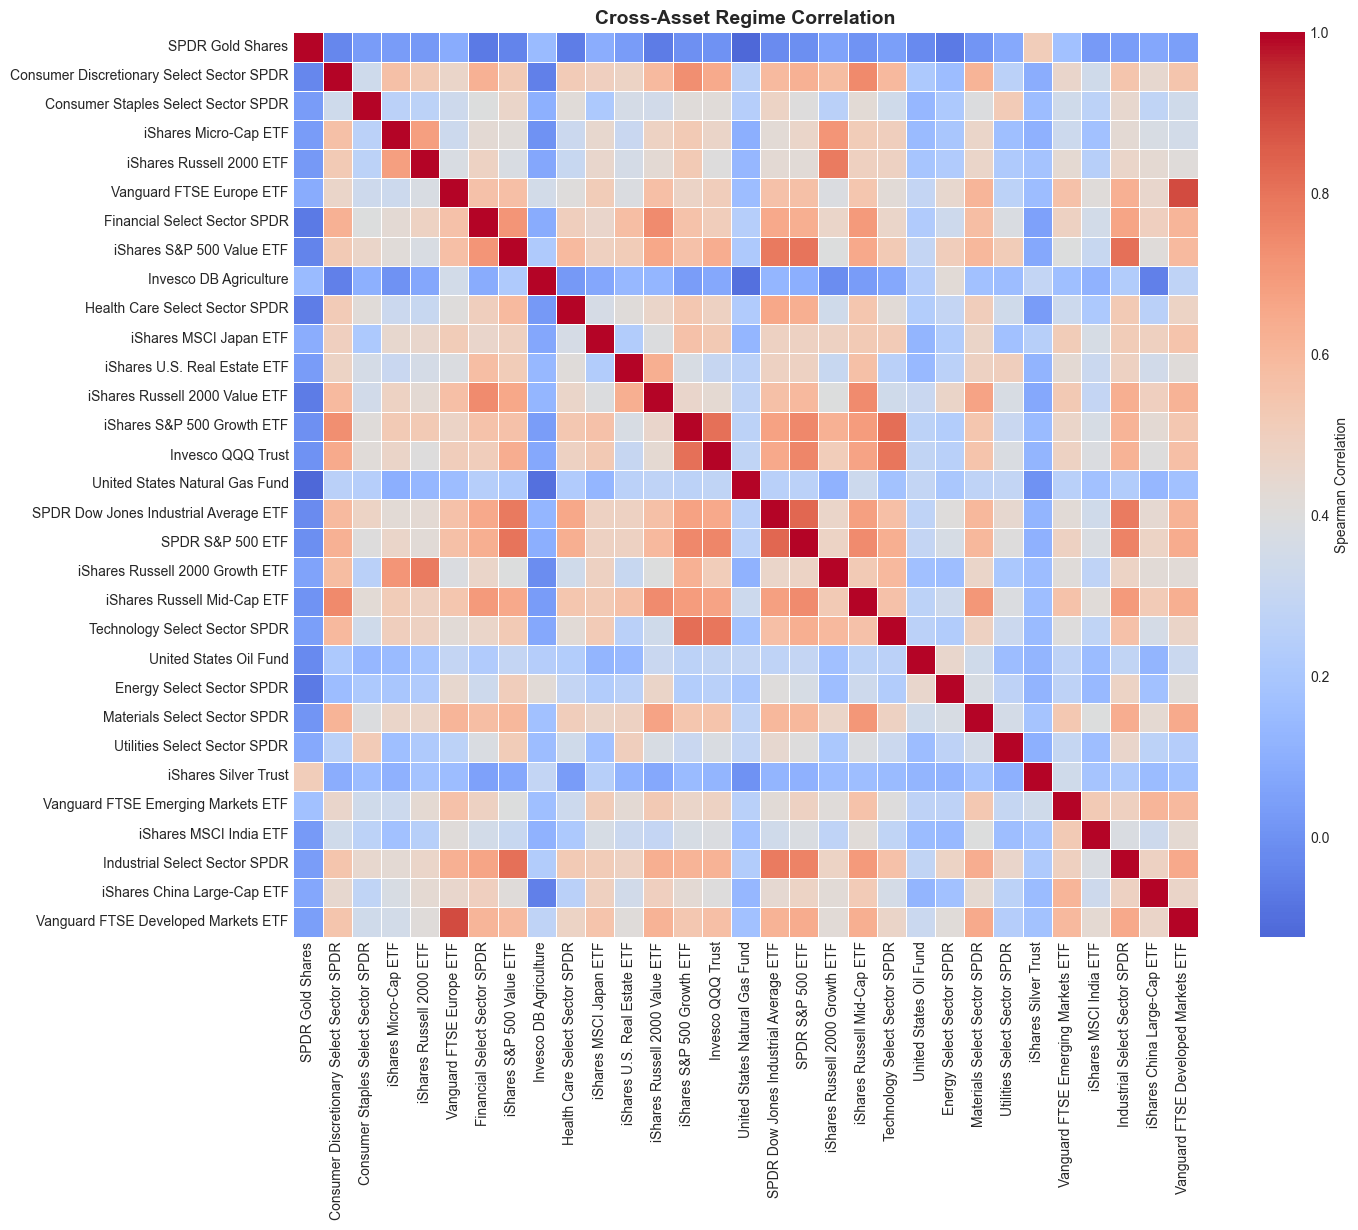


Strongest Cross-Asset Regime Correlations:

Highest Positive Correlations:


,Asset 1,Asset 2,Correlation
440,Vanguard FTSE Europe ETF,Vanguard FTSE Developed Markets ETF,0.8930
152,SPDR Dow Jones Industrial Average ETF,SPDR S&P 500 ETF,0.8314
203,iShares S&P 500 Growth ETF,Technology Select Sector SPDR,0.8150
385,iShares S&P 500 Value ETF,Industrial Select Sector SPDR,0.8088
104,iShares S&P 500 Growth ETF,Invesco QQQ Trust,0.8085
143,iShares S&P 500 Value ETF,SPDR S&P 500 ETF,0.8005
204,Invesco QQQ Trust,Technology Select Sector SPDR,0.7961
127,iShares S&P 500 Value ETF,SPDR Dow Jones Industrial Average ETF,0.7870
157,iShares Russell 2000 ETF,iShares Russell 2000 Growth ETF,0.7833
394,SPDR Dow Jones Industrial Average ETF,Industrial Select Sector SPDR,0.7783



Highest Negative Correlations:


,Asset 1,Asset 2,Correlation
0,SPDR Gold Shares,Consumer Discretionary Select Sector SPDR,-0.0356
21,SPDR Gold Shares,iShares S&P 500 Value ETF,-0.0419
414,Invesco DB Agriculture,iShares China Large-Cap ETF,-0.0525
29,Consumer Discretionary Select Sector SPDR,Invesco DB Agriculture,-0.0531
36,SPDR Gold Shares,Health Care Select Sector SPDR,-0.0588
66,SPDR Gold Shares,iShares Russell 2000 Value ETF,-0.0631
231,SPDR Gold Shares,Energy Select Sector SPDR,-0.0681
15,SPDR Gold Shares,Financial Select Sector SPDR,-0.0694
113,Invesco DB Agriculture,United States Natural Gas Fund,-0.1014
105,SPDR Gold Shares,United States Natural Gas Fund,-0.1234


In [43]:
# Calculate regime correlation (using aligned dates only)
regime_corr = regime_matrix.corr(method='spearman')  # Spearman for ordinal data

plt.figure(figsize=(max(10, len(models)*0.5), max(8, len(models)*0.4)))
sns.heatmap(regime_corr, annot=False, cmap='coolwarm', center=0.4, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Spearman Correlation'})
plt.title('Cross-Asset Regime Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStrongest Cross-Asset Regime Correlations:")
print("="*80)

# Get upper triangle to avoid duplicates
mask = np.triu(np.ones_like(regime_corr, dtype=bool), k=1)
regime_corr_upper = regime_corr.where(mask)

# Find top correlations
correlations = []
for col in regime_corr_upper.columns:
    for idx in regime_corr_upper.index:
        val = regime_corr_upper.loc[idx, col]
        if not pd.isna(val):
            correlations.append({
                'Asset 1': idx,
                'Asset 2': col,
                'Correlation': val
            })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print("\nHighest Positive Correlations:")
display(corr_df.head(10))

print("\nHighest Negative Correlations:")
display(corr_df.tail(10))

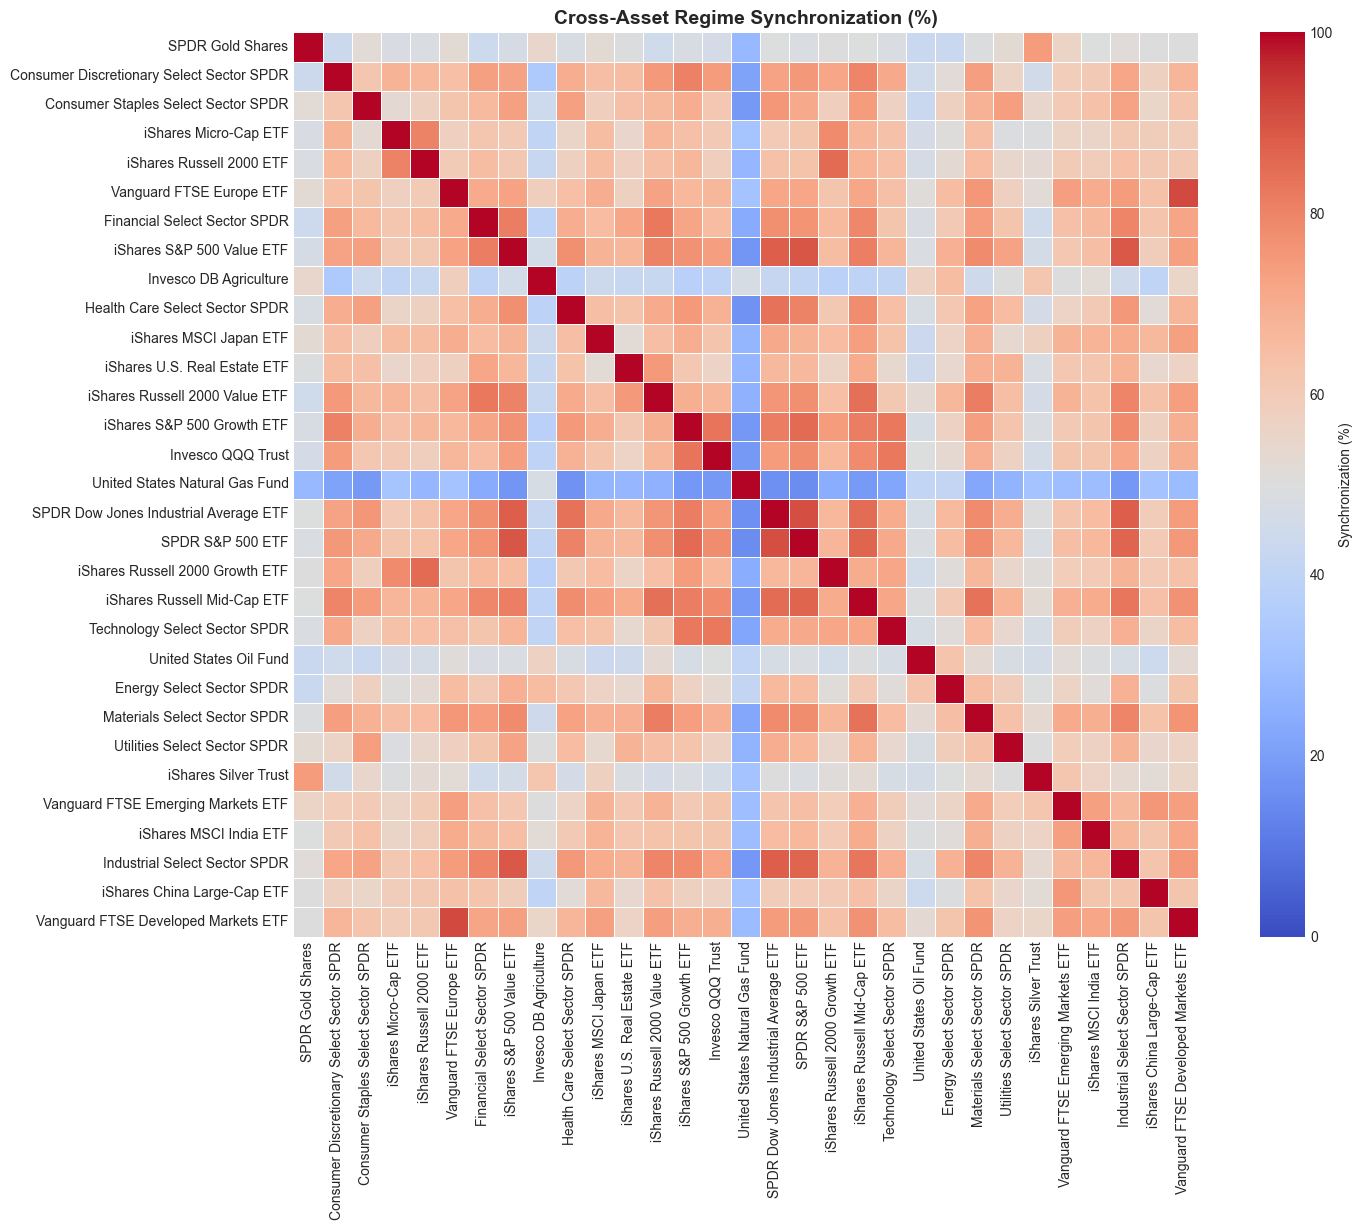


Asset Pairs with Highest Regime Synchronization:


,Asset 1,Asset 2,Sync %
164,Vanguard FTSE Europe ETF,Vanguard FTSE Developed Markets ETF,91.6447
360,SPDR Dow Jones Industrial Average ETF,SPDR S&P 500 ETF,90.6713
198,iShares S&P 500 Value ETF,SPDR S&P 500 ETF,89.1390
209,iShares S&P 500 Value ETF,Industrial Select Sector SPDR,89.0288
197,iShares S&P 500 Value ETF,SPDR Dow Jones Industrial Average ETF,87.8640
371,SPDR Dow Jones Industrial Average ETF,Industrial Select Sector SPDR,87.5000
384,SPDR S&P 500 ETF,Industrial Select Sector SPDR,86.5488
375,SPDR S&P 500 ETF,iShares Russell Mid-Cap ETF,86.3449
315,iShares S&P 500 Growth ETF,SPDR S&P 500 ETF,85.3375
127,iShares Russell 2000 ETF,iShares Russell 2000 Growth ETF,85.2672



Asset Pairs with Lowest Regime Synchronization:


,Asset 1,Asset 2,Sync %
346,United States Natural Gas Fund,SPDR S&P 500 ETF,15.5243
345,United States Natural Gas Fund,SPDR Dow Jones Industrial Average ETF,16.1297
239,Health Care Select Sector SPDR,United States Natural Gas Fund,16.4973
196,iShares S&P 500 Value ETF,United States Natural Gas Fund,17.9459
313,iShares S&P 500 Growth ETF,United States Natural Gas Fund,18.1189
357,United States Natural Gas Fund,Industrial Select Sector SPDR,18.3568
329,Invesco QQQ Trust,United States Natural Gas Fund,18.4432
71,Consumer Staples Select Sector SPDR,United States Natural Gas Fund,18.5730
348,United States Natural Gas Fund,iShares Russell Mid-Cap ETF,19.0919
43,Consumer Discretionary Select Sector SPDR,United States Natural Gas Fund,21.2973


In [44]:
# Calculate regime synchronization percentage
def calculate_regime_sync(regime_matrix: pd.DataFrame) -> pd.DataFrame:
    """Calculate percentage of time assets are in the same regime."""
    assets = regime_matrix.columns
    n_assets = len(assets)
    
    sync_matrix = pd.DataFrame(index=assets, columns=assets, dtype=float)
    
    for i, asset1 in enumerate(assets):
        for j, asset2 in enumerate(assets):
            if i == j:
                sync_matrix.loc[asset1, asset2] = 100.0
            else:
                # Find common dates
                common_dates = regime_matrix[[asset1, asset2]].dropna().index
                if len(common_dates) > 0:
                    same_regime = (regime_matrix.loc[common_dates, asset1] == 
                                  regime_matrix.loc[common_dates, asset2])
                    sync_matrix.loc[asset1, asset2] = same_regime.sum() / len(common_dates) * 100
    
    return sync_matrix.astype(float)

sync_matrix = calculate_regime_sync(regime_matrix)

plt.figure(figsize=(max(10, len(models)*0.5), max(8, len(models)*0.4)))
sns.heatmap(sync_matrix, annot=False, fmt='.1f', cmap='coolwarm', 
            vmin=0, vmax=100, square=True, linewidths=0.5,
            cbar_kws={'label': 'Synchronization (%)'})
plt.title('Cross-Asset Regime Synchronization (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Convert to long format
sync_data = []
for i, asset1 in enumerate(sync_matrix.index):
    for j, asset2 in enumerate(sync_matrix.columns):
        if i < j:  # Upper triangle only
            sync_data.append({
                'Asset 1': asset1,
                'Asset 2': asset2,
                'Sync %': sync_matrix.loc[asset1, asset2]
            })

sync_df = pd.DataFrame(sync_data).sort_values('Sync %', ascending=False)

print("\nAsset Pairs with Highest Regime Synchronization:")
print("="*80)
display(sync_df.head(10))

print("\nAsset Pairs with Lowest Regime Synchronization:")
print("="*80)
display(sync_df.tail(10).sort_values('Sync %'))

## 14. Identify Outliers and Anomalies

In [45]:
def identify_outliers_zscore(df: pd.DataFrame, columns: list, threshold: float = 3.0) -> pd.DataFrame:
    """
    Identify outliers using z-score method.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to analyze
    columns : list
        Columns to check for outliers
    threshold : float
        Z-score threshold (default: 3.0)
    
    Returns:
    --------
    pd.DataFrame : Rows with outlier values
    """
    outliers = pd.DataFrame()
    
    for col in columns:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            col_outliers = df[z_scores > threshold]
            
            if len(col_outliers) > 0:
                col_outliers['Outlier_Column'] = col
                col_outliers['Z_Score'] = z_scores[z_scores > threshold]
                outliers = pd.concat([outliers, col_outliers])
    
    return outliers

# Define columns to check
outlier_check_columns = [
    'KAMA_n', 'KAMA_n_fast', 'KAMA_n_slow', 'Filter_gamma',
    'Avg_Regime_Duration', 'Pct_Single_Period',
    'BIC', 'Changes_Per_100_Periods',
    'Regime_Diversity_Score'
]

# Filter available columns
available_outlier_cols = [col for col in outlier_check_columns if col in comprehensive_df.columns]

outliers = identify_outliers_zscore(comprehensive_df, available_outlier_cols, threshold=2.5)

print("Outlier Analysis (Z-score > 2.5):")
print("="*80)

if len(outliers) > 0:
    outlier_summary = outliers.groupby('Asset')['Outlier_Column'].apply(list).reset_index()
    outlier_summary.columns = ['Asset', 'Outlier Parameters']
    display(outlier_summary)
    
    print("\nDetailed Outlier Information:")
    display(outliers[['Asset', 'Outlier_Column', 'Z_Score']].sort_values('Z_Score', ascending=False))
else:
    print("✓ No significant outliers found")

Outlier Analysis (Z-score > 2.5):
✓ No significant outliers found


In [46]:
# IQR-based outlier detection
def identify_outliers_iqr(df: pd.DataFrame, columns: list, multiplier: float = 1.5) -> pd.DataFrame:
    """
    Identify outliers using IQR method.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to analyze
    columns : list
        Columns to check for outliers
    multiplier : float
        IQR multiplier (default: 1.5)
    
    Returns:
    --------
    pd.DataFrame : Rows with outlier values
    """
    outliers = pd.DataFrame()
    
    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - multiplier * IQR
            upper_bound = Q3 + multiplier * IQR
            
            col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].copy()
            
            if len(col_outliers) > 0:
                col_outliers['Outlier_Column'] = col
                col_outliers['Outlier_Value'] = col_outliers[col]
                col_outliers['Lower_Bound'] = lower_bound
                col_outliers['Upper_Bound'] = upper_bound
                outliers = pd.concat([outliers, col_outliers])
    
    return outliers

iqr_outliers = identify_outliers_iqr(comprehensive_df, available_outlier_cols, multiplier=1.5)

print("\nOutlier Analysis (IQR method):")
print("="*80)

if len(iqr_outliers) > 0:
    iqr_summary = iqr_outliers.groupby('Asset')['Outlier_Column'].apply(list).reset_index()
    iqr_summary.columns = ['Asset', 'Outlier Parameters']
    display(iqr_summary)
else:
    print("✓ No significant outliers found")


Outlier Analysis (IQR method):
✓ No significant outliers found


In [47]:
# Identify problematic models based on multiple criteria
def flag_problematic_models(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag models with multiple potential issues.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Comprehensive model data
    
    Returns:
    --------
    pd.DataFrame : Models with flags and issue counts
    """
    issues = df[['Asset']].copy()
    
    # Flag various issues
    issues['High_Instability'] = df['Pct_Single_Period'] > 20
    issues['Low_Differentiation'] = df['Regime_Diversity_Score'] > 0.6 if 'Regime_Diversity_Score' in df.columns else False
    issues['Short_Duration'] = df['Avg_Regime_Duration'] < 5
    issues['High_Switching'] = df['Changes_Per_100_Periods'] > 15
    issues['Poor_BIC'] = df['BIC'] > df['BIC'].quantile(0.75) if 'BIC' in df.columns else False
    
    # Count issues
    issue_cols = [col for col in issues.columns if col != 'Asset']
    issues['Total_Issues'] = issues[issue_cols].sum(axis=1)
    
    return issues.sort_values('Total_Issues', ascending=False)

problem_flags = flag_problematic_models(comprehensive_df)

print("Models Flagged for Potential Issues:")
print("="*80)

problem_models = problem_flags[problem_flags['Total_Issues'] > 0]
display(problem_models)

print(f"\n{len(problem_models)} out of {len(comprehensive_df)} models flagged with issues")

Models Flagged for Potential Issues:


,Asset,High_Instability,Low_Differentiation,Short_Duration,High_Switching,Poor_BIC,Total_Issues
15,United States Natural Gas Fund,False,False,False,False,True,1
8,Invesco DB Agriculture,False,False,False,False,True,1
29,iShares China Large-Cap ETF,False,False,False,False,True,1
27,iShares MSCI India ETF,False,False,False,False,True,1
25,iShares Silver Trust,False,False,False,False,True,1
21,United States Oil Fund,False,False,False,False,True,1
30,Vanguard FTSE Developed Markets ETF,False,False,False,False,True,1
3,iShares Micro-Cap ETF,False,False,False,False,True,1



8 out of 31 models flagged with issues


## 15. Generate Improvement Recommendations

In [48]:
def generate_improvement_recommendations(
    metadata_df: pd.DataFrame,
    duration_df: pd.DataFrame,
    performance_df: pd.DataFrame,
    stability_df: pd.DataFrame,
    problem_flags: pd.DataFrame,
    regime_returns_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Generate comprehensive improvement recommendations based on all analyses.
    
    Parameters:
    -----------
    metadata_df, duration_df, performance_df, stability_df, problem_flags, regime_returns_df
        Analysis dataframes
    
    Returns:
    --------
    pd.DataFrame : Recommendations for each asset with priority scores
    """
    recommendations = []
    
    for asset in metadata_df['Asset'].unique():
        asset_recs = {'Asset': asset, 'Recommendations': [], 'Priority': 0}
        
        # Check problem flags
        asset_flags = problem_flags[problem_flags['Asset'] == asset]
        if len(asset_flags) > 0:
            flags = asset_flags.iloc[0]
            
            if flags.get('High_Instability', False):
                asset_recs['Recommendations'].append("⚠️  HIGH INSTABILITY: Increase filter gamma or KAMA n to reduce single-period regimes")
                asset_recs['Priority'] += 3
            
            if flags.get('Low_Differentiation', False):
                asset_recs['Recommendations'].append("⚠️  LOW REGIME DIFFERENTIATION: Consider increasing MSR regimes or revising KAMA parameters")
                asset_recs['Priority'] += 2
            
            if flags.get('Short_Duration', False):
                asset_recs['Recommendations'].append("⚠️  SHORT REGIME DURATION: Increase minimum regime duration filter")
                asset_recs['Priority'] += 2
            
            if flags.get('High_Switching', False):
                asset_recs['Recommendations'].append("⚠️  HIGH SWITCHING FREQUENCY: Adjust KAMA sensitivity (increase n or n_slow)")
                asset_recs['Priority'] += 2
            
            if flags.get('Poor_BIC', False):
                asset_recs['Recommendations'].append("⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count")
                asset_recs['Priority'] += 1
        
        # Check regime returns
        asset_regime_returns = regime_returns_df[regime_returns_df['Asset'] == asset]
        if len(asset_regime_returns) >= 2:
            mean_diff = abs(asset_regime_returns['Mean'].max() - asset_regime_returns['Mean'].min())
            if mean_diff < 0.01:  # Very small annualized return difference
                asset_recs['Recommendations'].append("💡 WEAK REGIME SEPARATION: Regimes show similar returns; verify KAMA trend detection")
                asset_recs['Priority'] += 2
        
        # KAMA parameter checks
        asset_meta = metadata_df[metadata_df['Asset'] == asset].iloc[0]
        if asset_meta['KAMA_n'] < 10:
            asset_recs['Recommendations'].append("💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too sensitive to noise")
            asset_recs['Priority'] += 1
        
        if asset_meta['KAMA_n_slow'] > 100:
            asset_recs['Recommendations'].append("💡 KAMA SLOW PERIOD VERY HIGH: May miss important regime shifts")
            asset_recs['Priority'] += 1
        
        # Duration variability
        asset_dur = duration_df[duration_df['Asset'] == asset].iloc[0]
        if asset_dur['Std_Duration'] > asset_dur['Mean_Duration']:
            asset_recs['Recommendations'].append("💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints")
            asset_recs['Priority'] += 1
        
        # Add positive notes
        if asset_recs['Priority'] == 0:
            asset_recs['Recommendations'].append("✅ Model appears well-calibrated with no major issues detected")
        
        recommendations.append(asset_recs)
    
    recs_df = pd.DataFrame(recommendations)
    recs_df['N_Issues'] = recs_df['Recommendations'].apply(lambda x: len([r for r in x if '⚠️' in r or '💡' in r]))
    
    return recs_df.sort_values('Priority', ascending=False)

# Generate recommendations
if len(performance_df) > 0 and len(problem_flags) > 0:
    recommendations_df = generate_improvement_recommendations(
        metadata_df, duration_df, performance_df, stability_df, problem_flags, regime_returns_df
    )

    print("="*80)
    print("MODEL IMPROVEMENT RECOMMENDATIONS")
    print("="*80)
    print("\nPriority levels: Higher = More urgent\n")

    for _, row in recommendations_df.iterrows():
        print(f"\n{'='*80}")
        print(f"ASSET: {row['Asset']}")
        print(f"Priority Score: {row['Priority']} | Issues Found: {row['N_Issues']}")
        print(f"{'-'*80}")
        for rec in row['Recommendations']:
            print(f"  {rec}")
    
    print(f"\n{'='*80}")
    print(f"SUMMARY: {len(recommendations_df[recommendations_df['Priority'] > 0])} assets need attention")
    print(f"{'='*80}\n")
    
    # Export recommendations
    recommendations_export = recommendations_df.copy()
    recommendations_export['Recommendations'] = recommendations_export['Recommendations'].apply(lambda x: ' | '.join(x))
    
    print("\nRecommendations Summary Table:")
    display(recommendations_export[['Asset', 'Priority', 'N_Issues', 'Recommendations']])
else:
    print("❌ Cannot generate recommendations - missing required data")


MODEL IMPROVEMENT RECOMMENDATIONS

Priority levels: Higher = More urgent


ASSET: iShares Silver Trust
Priority Score: 3 | Issues Found: 3
--------------------------------------------------------------------------------
  ⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count
  💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too sensitive to noise
  💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints

ASSET: United States Natural Gas Fund
Priority Score: 2 | Issues Found: 2
--------------------------------------------------------------------------------
  ⚠️  POOR MODEL FIT: Review parameter choices or consider alternative regime count
  💡 HIGH DURATION VARIABILITY: Consider tightening minimum duration constraints

ASSET: iShares MSCI Japan ETF
Priority Score: 2 | Issues Found: 2
--------------------------------------------------------------------------------
  💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too sensitive to noise
  💡 HIGH DUR

,Asset,Priority,N_Issues,Recommendations
25,iShares Silver Trust,3,3,⚠️ POOR MODEL FIT: Review parameter choices o...
15,United States Natural Gas Fund,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
10,iShares MSCI Japan ETF,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
29,iShares China Large-Cap ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
27,iShares MSCI India ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
21,United States Oil Fund,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
20,Technology Select Sector SPDR,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
18,iShares Russell 2000 Growth ETF,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
13,iShares S&P 500 Growth ETF,2,2,💡 KAMA EFFICIENCY PERIOD TOO SHORT: May be too...
30,Vanguard FTSE Developed Markets ETF,2,2,⚠️ POOR MODEL FIT: Review parameter choices o...
